# Flight Delay Prediction — Exhaustive EDA
### Dataset : NYC Flights 2013  |  336,776 rows × 41 features  |  Binary classification

---

## 1. Business problem
Airlines and airports face enormous downstream costs every time a flight is delayed — crew reassignment, fuel burn, gate congestion, passenger compensation. A model that flags *which* flights are likely to be delayed before take-off lets operations teams re-route, re-staff, or pre-notify passengers. The same pipeline can be repurposed for any scheduled-service domain (logistics, ride-hailing, field service).

**Target:** `is_delayed` — binary flag, `1` if a flight's arrival delay exceeds **15 minutes** (the FAA's official "on-time" threshold), else `0`.

**Data sources combined** (all from `nycflights13`, real 2013 data for all flights departing from the three NYC airports — JFK, LGA, EWR):
- `flights` — 336,776 flight records × 19 cols
- `weather` — hourly weather at origin × 15 cols
- `planes` — aircraft metadata × 9 cols
- `airlines` + `airports` — lookup tables

After joining on `time_hour+origin`, `tailnum`, `carrier`, and `dest`, we get **336,776 × 41** — a real-world, enterprise-scale EDA problem.

## 2. EDA scope covered in this notebook
1. Data import & integration
2. Data characteristics (shape, dtypes, memory, cardinality)
3. Missing-data handling (MCAR/MAR diagnosis, drop vs impute)
4. Duplicate-data handling
5. Statistical analysis (descriptive + inferential)
6. Univariate / Bivariate / Multivariate analysis
7. Correlation + **multicollinearity (VIF)**  → feature drop with justification
8. Outlier detection (IQR + z-score) and handling (winsorization)
9. Transformation (log, Box-Cox) and scaling (Standard, MinMax)
10. Summary observations & insights for downstream modelling


## Section 1 — Environment setup

In [1]:
# Core stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats
from scipy.stats import skew, kurtosis, zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Preprocessing / feature selection
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif

# Missingness
import missingno as msno

# Display
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('Setup complete.')

Setup complete.


## Section 2 — Data import and integration

We pull the five raw tables from `nycflights13` and join them on their natural keys. Any one of these tables in isolation gives a narrow view of a flight — joined, they describe the flight plus the weather, plus the plane's hardware, plus the route geography.


In [2]:
from nycflights13 import flights, weather, planes, airports, airlines

print('--- Raw table shapes ---')
for name, tbl in [('flights', flights), ('weather', weather),
                  ('planes', planes), ('airports', airports), ('airlines', airlines)]:
    print(f'{name:10s} {tbl.shape}')

--- Raw table shapes ---
flights    (336776, 19)
weather    (26115, 15)
planes     (3322, 9)
airports   (1458, 8)
airlines   (16, 2)


### 2.1 Join strategy
- `flights` ⟵ LEFT JOIN `weather` on (`origin`, `time_hour`) → hourly weather at the origin
- `flights` ⟵ LEFT JOIN `planes` on `tailnum` → aircraft metadata (manufacturer, engines, seats, age)
- `flights` ⟵ LEFT JOIN `airlines` on `carrier` → readable carrier name
- `flights` ⟵ LEFT JOIN `airports` on `dest` → destination lat/lon/altitude

LEFT joins preserve every flight record; unmatched rows will surface as NaN and be diagnosed in the missing-data section.

In [3]:
# Rename to avoid collisions
planes_r  = planes.rename(columns={'year':'plane_year','type':'plane_type','speed':'plane_speed'})
weather_r = weather.drop(columns=['year','month','day','hour'])  # keep time_hour as single join key
airports_r = airports[['faa','name','lat','lon','alt']].rename(
    columns={'faa':'dest','name':'dest_name','lat':'dest_lat','lon':'dest_lon','alt':'dest_alt'})
airlines_r = airlines.rename(columns={'name':'carrier_name'})

df = (flights
      .merge(weather_r,  on=['origin','time_hour'], how='left')
      .merge(planes_r,   on='tailnum',               how='left')
      .merge(airlines_r, on='carrier',               how='left')
      .merge(airports_r, on='dest',                  how='left'))

print('Merged shape:', df.shape)
df.head(3)

Merged shape: (336776, 41)


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,plane_year,plane_type,manufacturer,model,engines,seats,plane_speed,engine,carrier_name,dest_name,dest_lat,dest_lon,dest_alt
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,1999.0,Fixed wing multi engine,BOEING,737-824,2.0,149.0,NaN,Turbo-fan,United Air Lines Inc.,George Bush Intercontinental,29.984433,-95.341442,97.0
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0,1998.0,Fixed wing multi engine,BOEING,737-824,2.0,149.0,NaN,Turbo-fan,United Air Lines Inc.,George Bush Intercontinental,29.984433,-95.341442,97.0
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0,1990.0,Fixed wing multi engine,BOEING,757-223,2.0,178.0,NaN,Turbo-fan,American Airlines Inc.,Miami Intl,25.793250,-80.290556,8.0


## Section 3 — Data characteristics

Before any cleaning decisions, we map the territory: how big is the dataset, what types do the columns hold, how much memory do they consume, how many distinct values are there, and which columns are numeric vs categorical.

In [4]:
print('Rows   :', df.shape[0])
print('Cols   :', df.shape[1])
print('Memory :', f'{df.memory_usage(deep=True).sum()/1e6:.1f} MB')

Rows   : 336776
Cols   : 41
Memory : 149.6 MB


In [5]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 41 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  str    
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  str    
 12  origin          336776 non-null  str    
 13  dest            336776 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  int64  
 16  hour            336776 non-null  int64  
 17  minute          33677

In [6]:
# Dtype breakdown
dtype_counts = df.dtypes.value_counts()
print('Data-type breakdown:')
print(dtype_counts)

Data-type breakdown:
float64    21
str        11
int64       9
Name: count, dtype: int64


In [7]:
# Separate numeric vs categorical for the rest of the EDA
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'Numeric columns    ({len(num_cols)}):', num_cols)
print(f'Categorical columns({len(cat_cols)}):', cat_cols)

Numeric columns    (30): ['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay', 'arr_time', 'sched_arr_time', 'arr_delay', 'flight', 'air_time', 'distance', 'hour', 'minute', 'temp', 'dewp', 'humid', 'wind_dir', 'wind_speed', 'wind_gust', 'precip', 'pressure', 'visib', 'plane_year', 'engines', 'seats', 'plane_speed', 'dest_lat', 'dest_lon', 'dest_alt']
Categorical columns(11): ['carrier', 'tailnum', 'origin', 'dest', 'time_hour', 'plane_type', 'manufacturer', 'model', 'engine', 'carrier_name', 'dest_name']


In [8]:
# Cardinality of every column (distinct-value count)
card = df.nunique().sort_values(ascending=False).to_frame('n_unique')
card['pct_unique'] = (card['n_unique'] / len(df) * 100).round(2)
card

,n_unique,pct_unique
time_hour,6936,2.06
tailnum,4043,1.20
flight,3844,1.14
humid,2442,0.73
arr_time,1411,0.42
dep_time,1318,0.39
sched_arr_time,1163,0.35
sched_dep_time,1021,0.30
arr_delay,577,0.17
dep_delay,527,0.16


**Reading the cardinality table:** columns with 100 % unique values (e.g. flight identifiers) are row IDs and carry no generalisable signal. Columns with extremely low cardinality (`year` = 1) are constants and should be dropped. These are first-pass clean-up candidates.

In [9]:
# Numeric summary
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
year,336776.0,2013.000000,0.000000,2013.000000,2013.000000,2013.000000,2013.000000,2013.000000
month,336776.0,6.548510,3.414457,1.000000,4.000000,7.000000,10.000000,12.000000
day,336776.0,15.710787,8.768607,1.000000,8.000000,16.000000,23.000000,31.000000
dep_time,328521.0,1349.109947,488.281791,1.000000,907.000000,1401.000000,1744.000000,2400.000000
sched_dep_time,336776.0,1344.254840,467.335756,106.000000,906.000000,1359.000000,1729.000000,2359.000000
dep_delay,328521.0,12.639070,40.210061,-43.000000,-5.000000,-2.000000,11.000000,1301.000000
arr_time,328063.0,1502.054999,533.264132,1.000000,1104.000000,1535.000000,1940.000000,2400.000000
sched_arr_time,336776.0,1536.380220,497.457142,1.000000,1124.000000,1556.000000,1945.000000,2359.000000
arr_delay,327346.0,6.895377,44.633292,-86.000000,-17.000000,-5.000000,14.000000,1272.000000
flight,336776.0,1971.923620,1632.471938,1.000000,553.000000,1496.000000,3465.000000,8500.000000


In [10]:
# Categorical summary
df[cat_cols].describe().T

,count,unique,top,freq
carrier,336776,16,UA,58665
tailnum,334264,4043,N725MQ,575
origin,336776,3,EWR,120835
dest,336776,105,ORD,17283
time_hour,336776,6936,2013-09-13T12:00:00Z,94
plane_type,284170,3,Fixed wing multi engine,282074
manufacturer,284170,35,BOEING,82912
model,284170,127,A320-232,45831
engine,284170,6,Turbo-fan,240915
carrier_name,336776,16,United Air Lines Inc.,58665


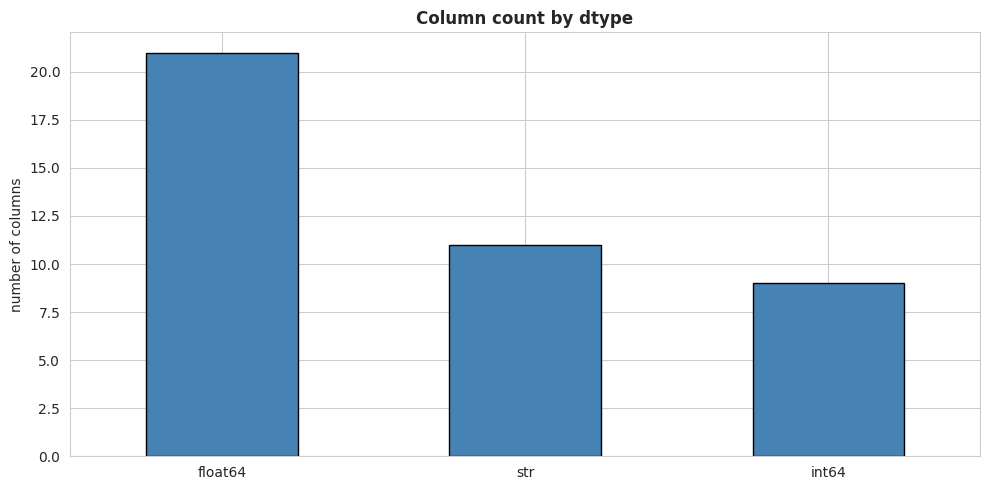

In [11]:
# Visualise the dtype split
dtype_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Column count by dtype')
plt.ylabel('number of columns'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## Section 4 — Missing-data handling

Three questions drive every decision here:
1. **How much is missing?** — < 5 % we impute, 5–40 % we investigate, > 40 % we usually drop the column.
2. **Is the missingness structured?** — the `missingno` matrix and heatmap tell us whether rows with missing `wind_gust` also tend to have missing `pressure` (MAR / MCAR diagnosis).
3. **Is the missingness informative?** — sometimes NaN itself is a signal (e.g. `dep_time` is NaN only when the flight was cancelled). Dropping those rows erases real information.

In [12]:
missing = pd.DataFrame({
    'n_missing':   df.isna().sum(),
    'pct_missing': (df.isna().mean()*100).round(2)
}).query('n_missing > 0').sort_values('pct_missing', ascending=False)
missing

,n_missing,pct_missing
plane_speed,335813,99.71
wind_gust,256391,76.13
plane_year,57912,17.20
manufacturer,52606,15.62
engines,52606,15.62
seats,52606,15.62
model,52606,15.62
plane_type,52606,15.62
engine,52606,15.62
pressure,38788,11.52


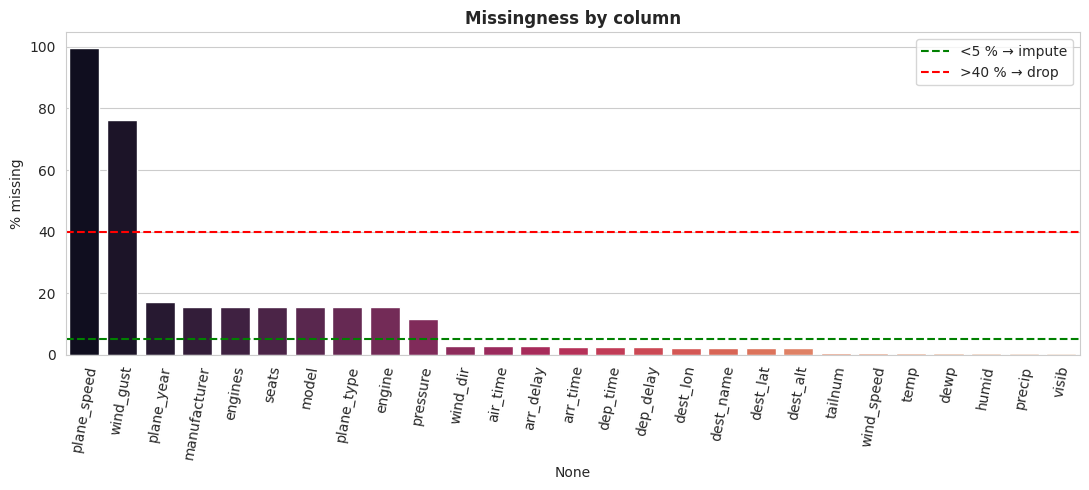

In [13]:
# Bar chart of missingness (only cols with > 0 missing)
plt.figure(figsize=(11,5))
sns.barplot(x=missing.index, y=missing['pct_missing'],
            palette='rocket')
plt.xticks(rotation=80)
plt.ylabel('% missing'); plt.title('Missingness by column')
plt.axhline(5,  ls='--', c='green', label='<5 % → impute')
plt.axhline(40, ls='--', c='red',   label='>40 % → drop')
plt.legend(); plt.tight_layout(); plt.show()

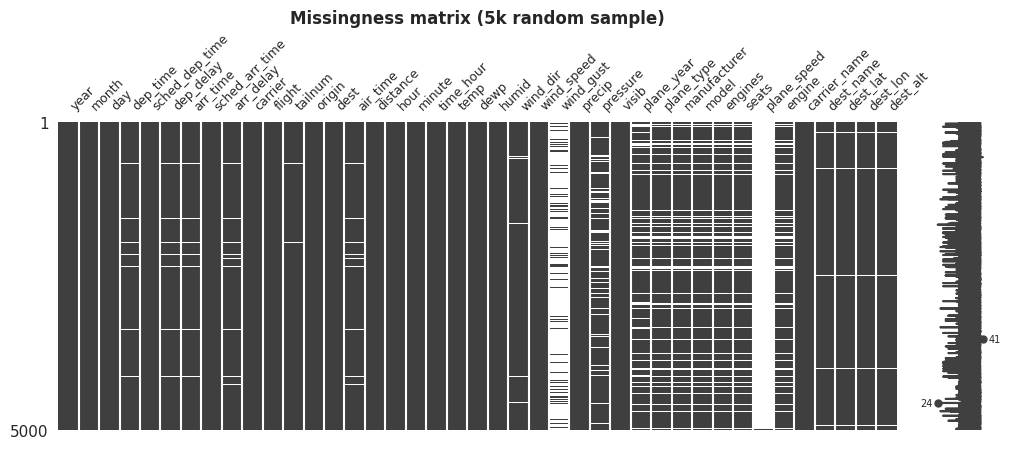

In [14]:
# Missingness matrix — structural pattern
msno.matrix(df.sample(5000, random_state=RANDOM_SEED),
            figsize=(12, 4), fontsize=9)
plt.title('Missingness matrix (5k random sample)')
plt.show()

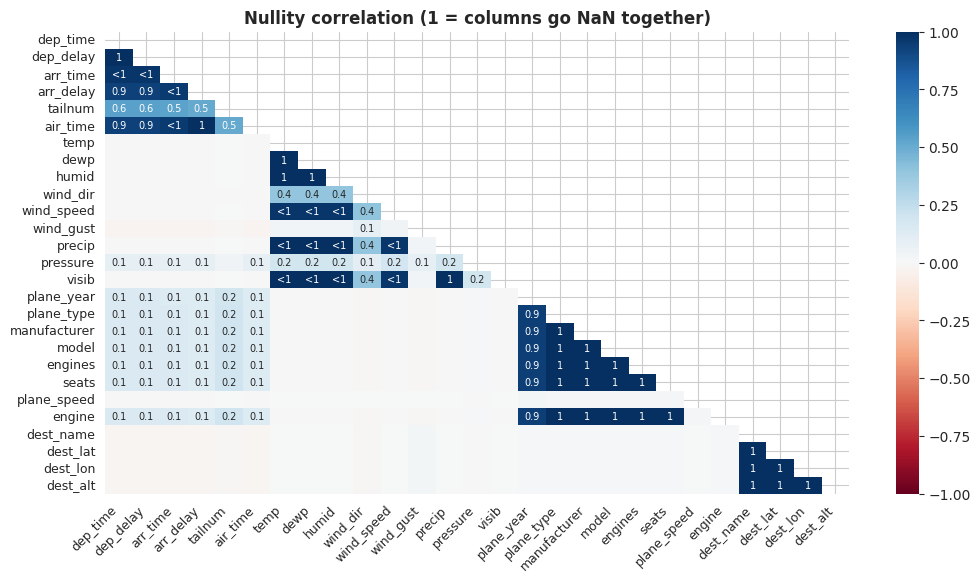

In [15]:
# Missingness correlation heatmap — do NaNs co-occur?
msno.heatmap(df, figsize=(12, 6), fontsize=9)
plt.title('Nullity correlation (1 = columns go NaN together)')
plt.show()

### 4.1 Drop/impute decisions

| Column | % missing | Decision | Reason |
|---|---|---|---|
| `plane_speed` | ~99.7 % | **drop** | too sparse, no imputation can recover signal |
| `wind_gust` | ~76 % | **drop** | highly correlated missingness with `wind_speed`, which we already have |
| `pressure` | ~11.5 % | **impute (median)** | borderline but pressure is weather-stable, median is safe |
| `plane_year`, `engines`, `seats`, aircraft-side cols | ~17 % | **impute (median / mode)** | missing because tail number not in planes table; fall back to per-carrier median |
| `dep_time`, `arr_time`, `air_time`, `arr_delay` | ~2.5 % | **drop rows** | these rows are cancelled flights — no arrival means no target; excluding is honest |
| `temp`, `dewp`, `humid`, `visib`, `precip`, `wind_speed` | <1 % | **impute (median)** | tiny gap, imputation has negligible effect |
| `wind_dir` | ~3 % | **impute (median)** | circular variable — median is reasonable for a single missing hour |
| `tailnum` | 0.7 % | **drop rows** | rare; no reliable way to recover aircraft ID |
| destination-side (`dest_*`) | 2.3 % | **drop rows** | handful of flights to airports missing from lookup |


In [16]:
# Apply drop/impute decisions
DROP_COLS       = ['plane_speed', 'wind_gust']
DROP_NA_ROWS    = ['dep_time', 'arr_time', 'air_time', 'arr_delay', 'tailnum', 'dest_lat']
IMPUTE_MEDIAN   = ['pressure', 'plane_year', 'engines', 'seats',
                   'temp', 'dewp', 'humid', 'visib', 'precip',
                   'wind_speed', 'wind_dir']
IMPUTE_MODE     = ['plane_type', 'manufacturer', 'model', 'engine']

df_clean = df.drop(columns=DROP_COLS)
df_clean = df_clean.dropna(subset=DROP_NA_ROWS)

for c in IMPUTE_MEDIAN:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in IMPUTE_MODE:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(df_clean[c].mode().iloc[0])

print(f'Before : {df.shape}')
print(f'After  : {df_clean.shape}')
print(f'Rows dropped : {len(df) - len(df_clean):,}  ({(len(df)-len(df_clean))/len(df)*100:.2f} %)')
print(f'Remaining NaN: {df_clean.isna().sum().sum()}')

Before : (336776, 41)
After  : (319809, 39)
Rows dropped : 16,967  (5.04 %)
Remaining NaN: 0


In [17]:
# Confirm zero missing
assert df_clean.isna().sum().sum() == 0
print('✅ Dataset has zero missing values after handling.')

✅ Dataset has zero missing values after handling.


## Section 5 — Duplicate handling

In a transactional dataset like this, a true duplicate would be two flight records with identical values across every column including `time_hour`, `flight`, `tailnum`. That's unlikely in real operations data but we verify — and we also check for *logical duplicates* (same flight number, same scheduled time, same tail — which would indicate a data pipeline bug).

In [18]:
print('Exact duplicates :', df_clean.duplicated().sum())
print('Logical duplicates (flight, time_hour, tailnum):',
      df_clean.duplicated(subset=['flight','time_hour','tailnum']).sum())

Exact duplicates : 0
Logical duplicates (flight, time_hour, tailnum): 0


In [19]:
# Remove any found
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Removed {before - len(df_clean)} duplicate rows. New shape: {df_clean.shape}')

Removed 0 duplicate rows. New shape: (319809, 39)


## Section 6 — Target variable engineering

The FAA defines a flight as "on-time" if it arrives within 15 minutes of its scheduled arrival. We mirror that convention.

**⚠️ Data leakage check** — `arr_delay` is the *source* of the target (`is_delayed = arr_delay > 15`). If we kept it as a predictor we'd get a trivially perfect model with zero learning signal — so we drop it explicitly below. `dep_delay`, `dep_time`, `arr_time`, `air_time` are all recorded *after* or *during* the flight. For a true *pre-flight* prediction model these would leak the answer too; because this notebook is EDA-focused (not production modelling), we keep them for analysis but flag them in the final summary.

In [20]:
df_clean['is_delayed'] = (df_clean['arr_delay'] > 15).astype(int)
print('Class distribution:')
print(df_clean['is_delayed'].value_counts())
print()
print('Class proportions:')
print(df_clean['is_delayed'].value_counts(normalize=True).round(4))

Class distribution:
is_delayed
0    243748
1     76061
Name: count, dtype: int64

Class proportions:
is_delayed
0    0.7622
1    0.2378
Name: proportion, dtype: float64


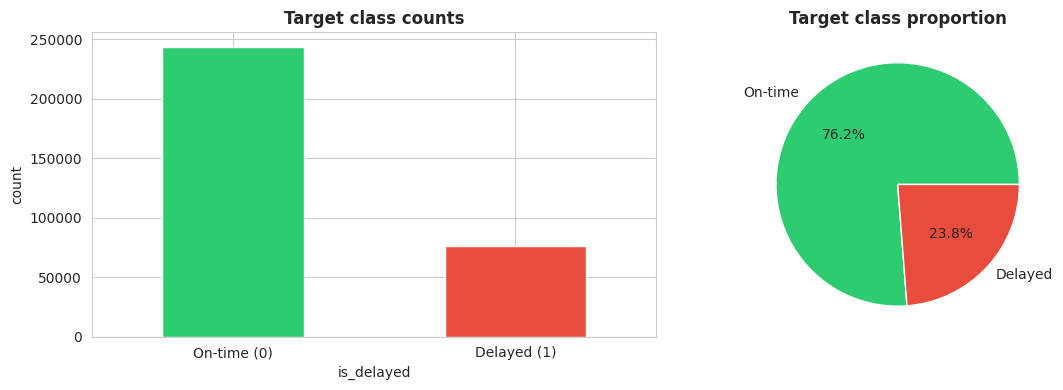

In [21]:
# Target plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_clean['is_delayed'].value_counts().plot(
    kind='bar', ax=ax[0], color=['#2ecc71','#e74c3c'])
ax[0].set_xticklabels(['On-time (0)','Delayed (1)'], rotation=0)
ax[0].set_title('Target class counts'); ax[0].set_ylabel('count')

df_clean['is_delayed'].value_counts(normalize=True).plot(
    kind='pie', ax=ax[1], autopct='%1.1f%%',
    colors=['#2ecc71','#e74c3c'],
    labels=['On-time','Delayed'])
ax[1].set_ylabel(''); ax[1].set_title('Target class proportion')
plt.tight_layout(); plt.show()

**Observation:** ~20 % of flights are delayed > 15 min. Moderate imbalance (not severe). For modelling we'd use class-weighted loss or SMOTE; for EDA the imbalance is not extreme enough to distort group statistics.

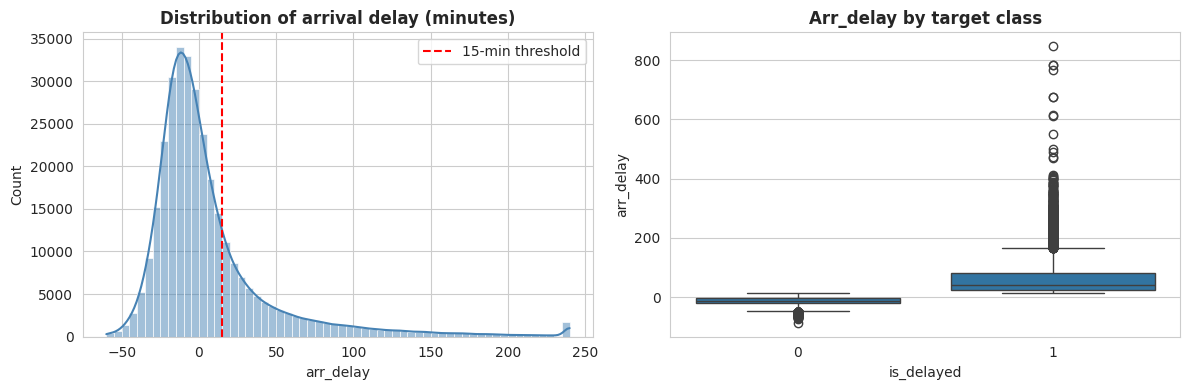

In [22]:
# Distribution of the raw continuous version of the target
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df_clean['arr_delay'].clip(-60, 240), bins=60, kde=True, color='steelblue')
plt.axvline(15, ls='--', c='red', label='15-min threshold')
plt.title('Distribution of arrival delay (minutes)')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(x='is_delayed', y='arr_delay', data=df_clean.sample(50000, random_state=RANDOM_SEED))
plt.title('Arr_delay by target class')
plt.tight_layout(); plt.show()

In [23]:
# Drop constants, identifiers, AND the leakage column arr_delay
# arr_delay was used to BUILD is_delayed — keeping it would give a perfect predictor and no learning signal.
print('year column unique values:', df_clean['year'].unique())
DROP_ID_CONST_LEAK = ['year', 'flight', 'tailnum', 'time_hour', 'dest_name', 'arr_delay']
df_clean = df_clean.drop(columns=[c for c in DROP_ID_CONST_LEAK if c in df_clean.columns])
print('Shape after dropping constants / IDs / target-source:', df_clean.shape)

year column unique values: [2013]
Shape after dropping constants / IDs / target-source: (319809, 34)


## Section 7 — Univariate analysis

We examine each column in isolation before looking at relationships. For numeric columns we look at the distribution shape, central tendency, spread, skewness, and kurtosis. For categorical columns we look at level counts and concentration.

In [24]:
# Refresh num/cat lists after cleaning
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()

# We'll exclude the target from the predictor list when plotting
predictors_num = [c for c in num_cols if c != 'is_delayed']
print(f'Numeric predictors: {len(predictors_num)}')
print(f'Categorical predictors: {len(cat_cols)}')

Numeric predictors: 25
Categorical predictors: 8


### 7.1 Numerical — histograms (distribution shape)

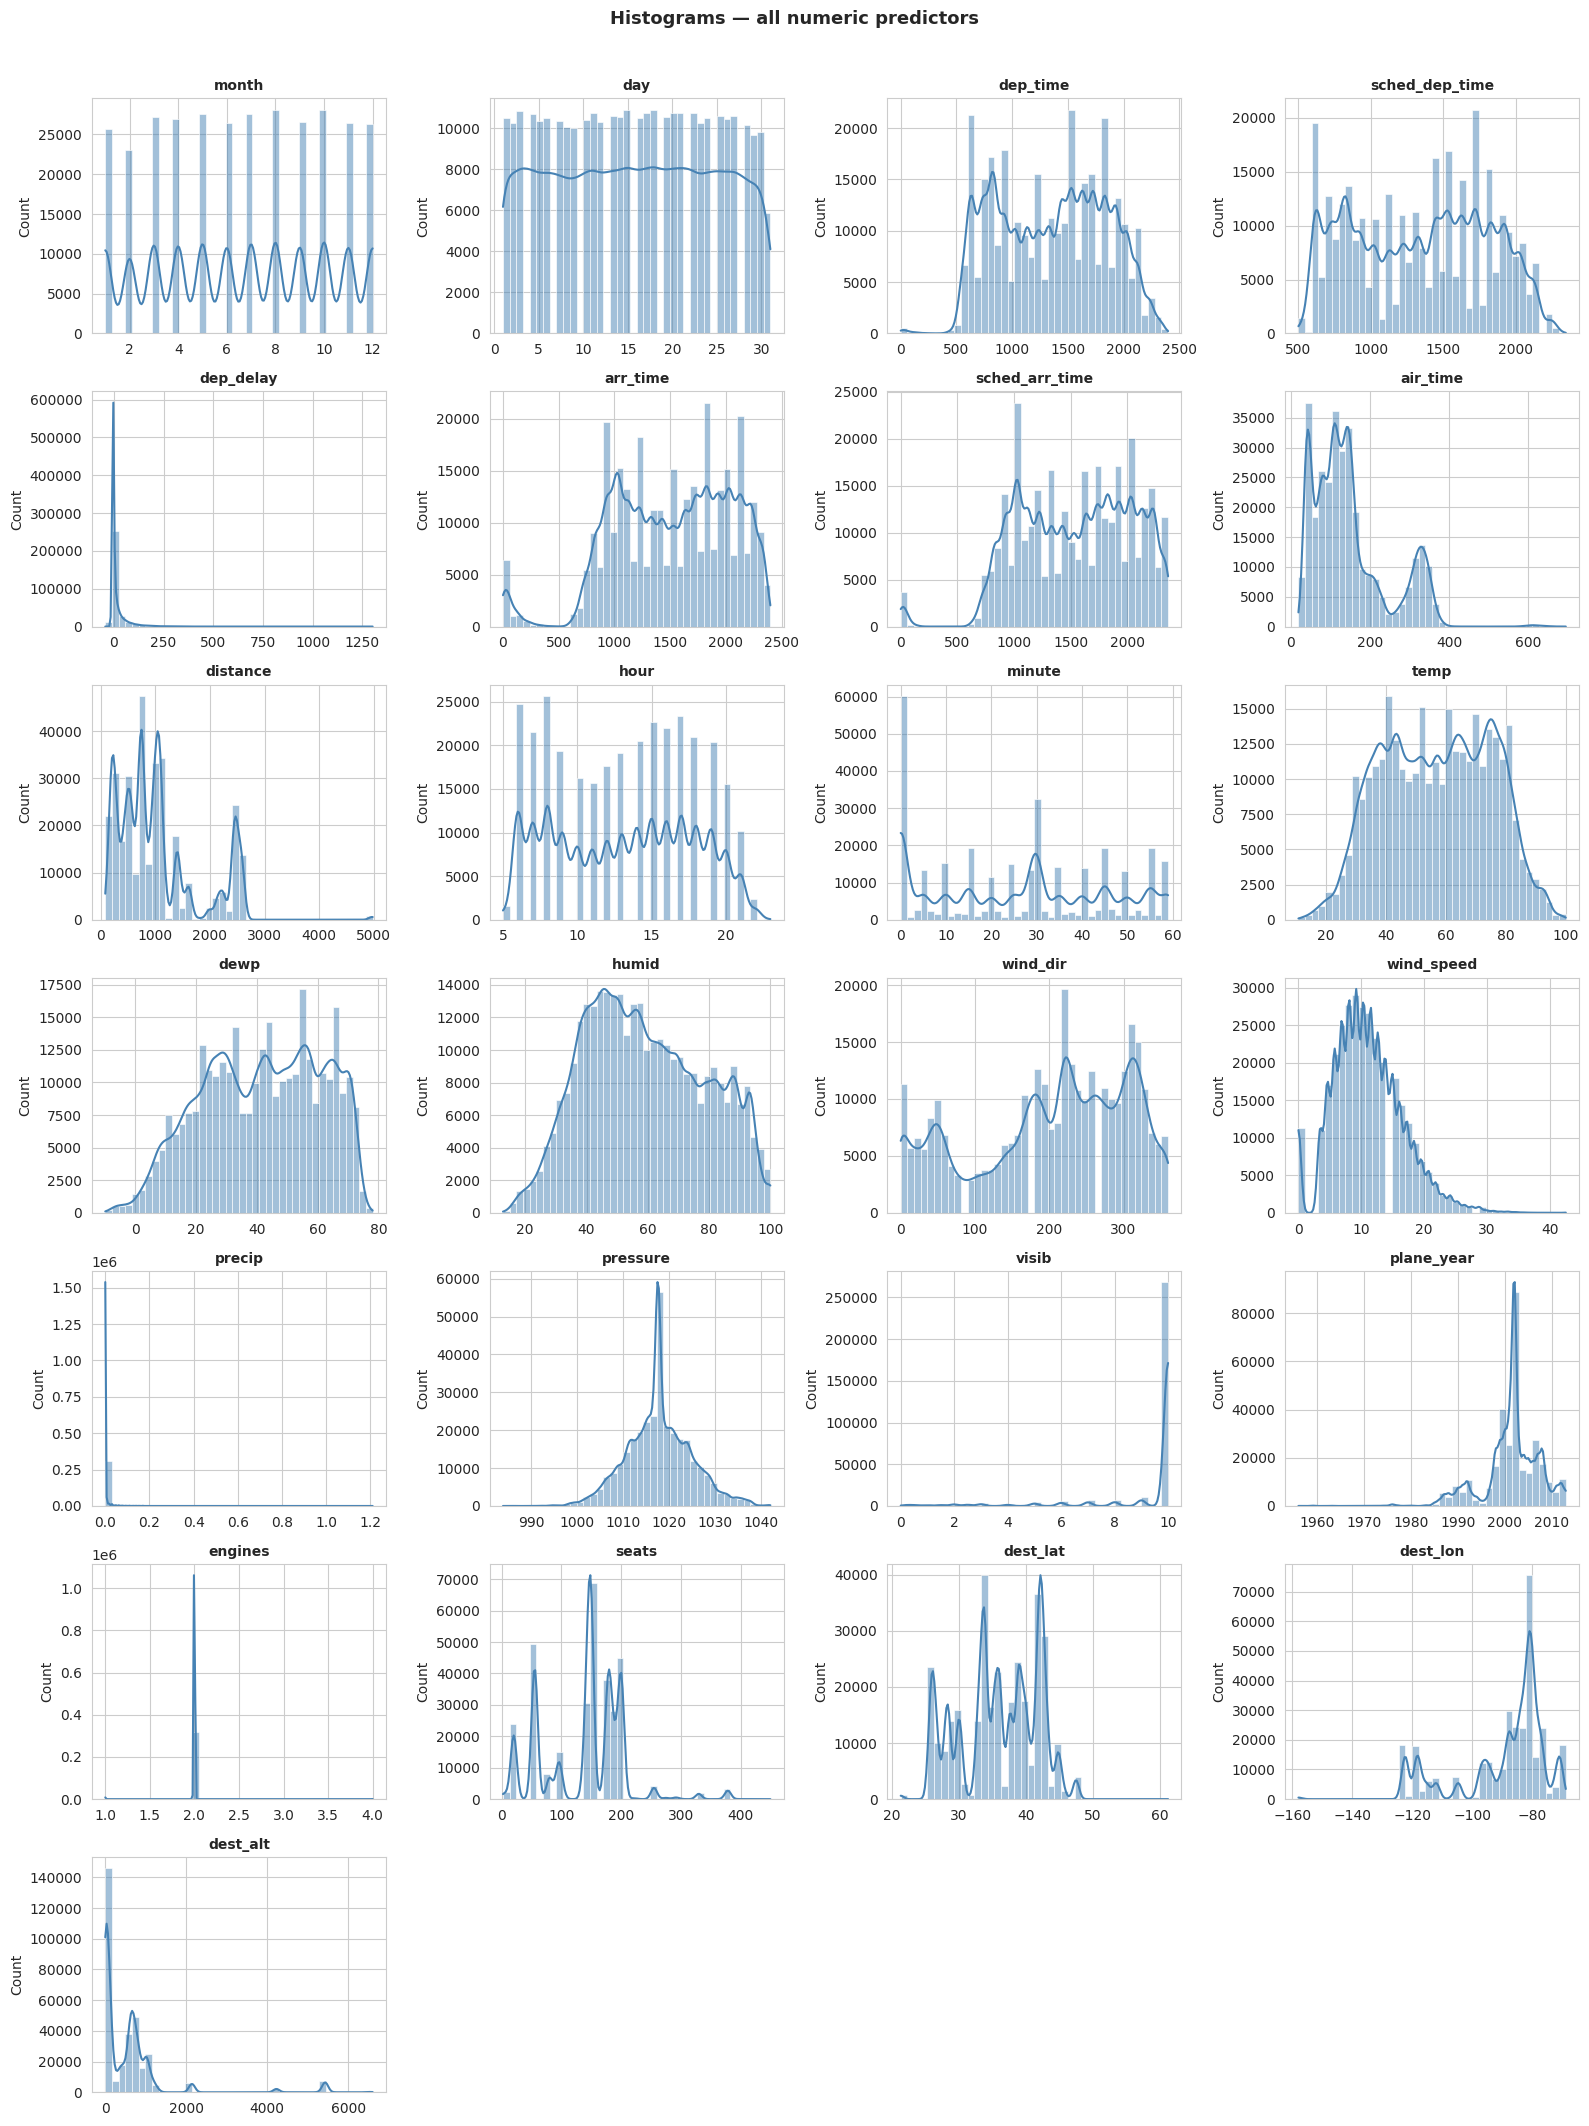

In [25]:
# Grid of histograms
n = len(predictors_num)
ncols, nrows = 4, int(np.ceil(n/4))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
for i, col in enumerate(predictors_num):
    ax = axes.flat[i]
    sns.histplot(df_clean[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
for j in range(i+1, nrows*ncols):
    axes.flat[j].axis('off')
plt.suptitle('Histograms — all numeric predictors', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 7.2 Numerical — boxplots (spread + outlier preview)

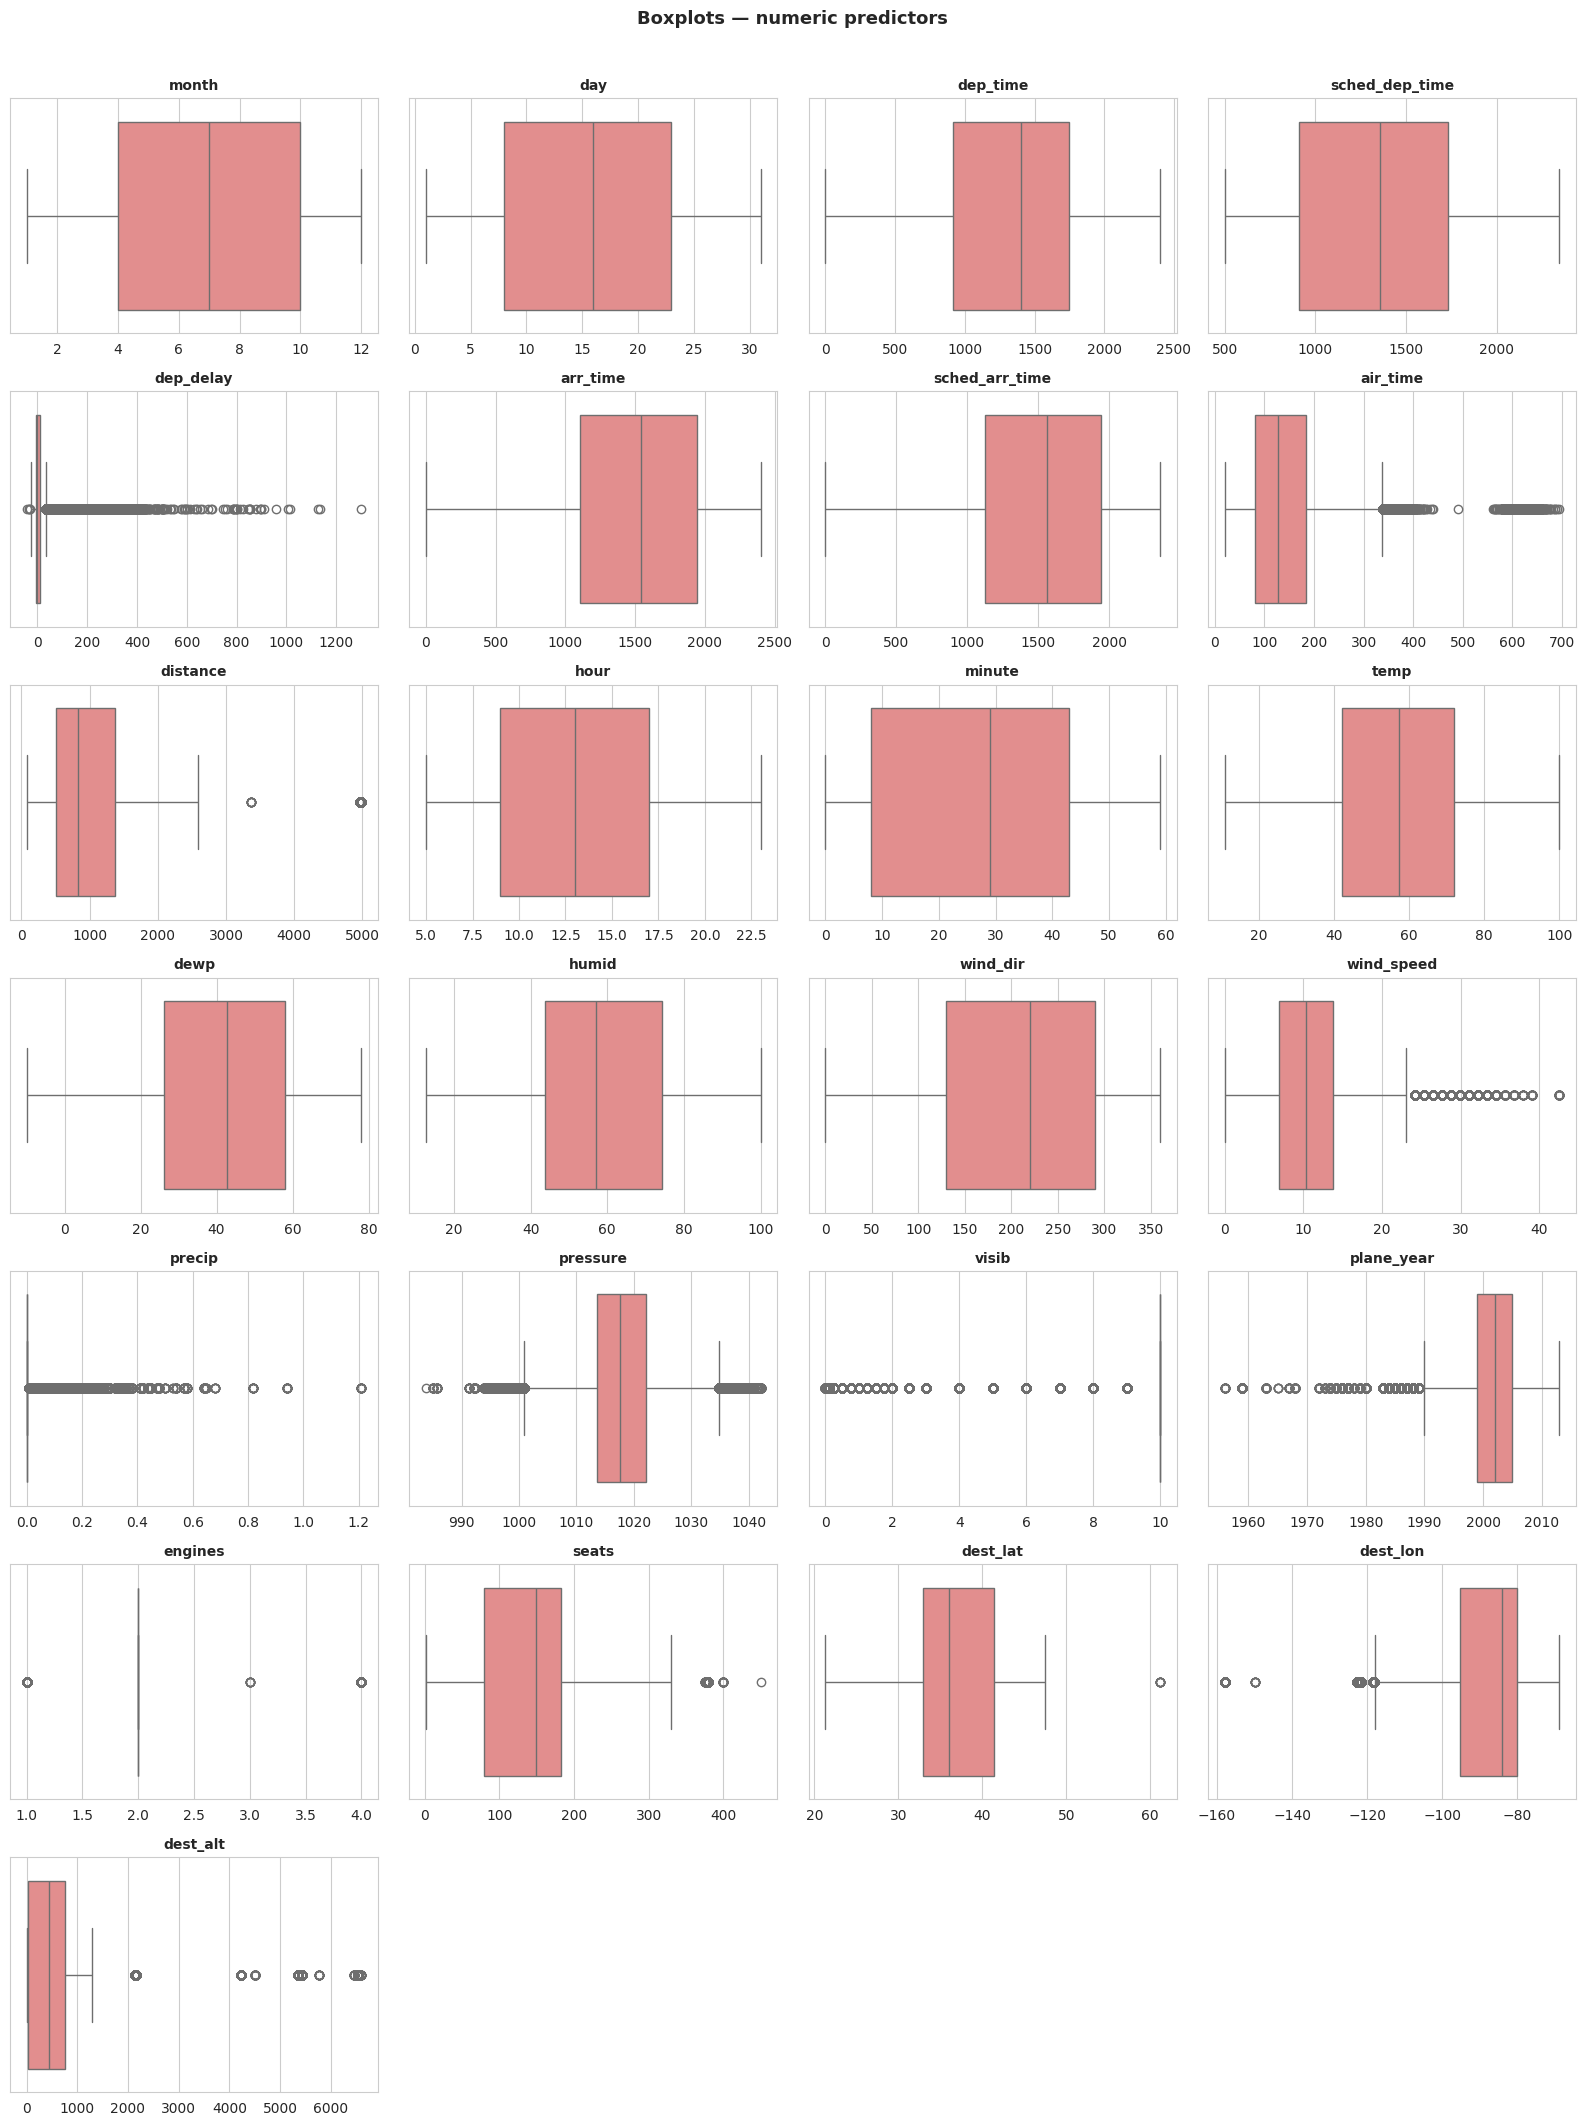

In [26]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
for i, col in enumerate(predictors_num):
    ax = axes.flat[i]
    sns.boxplot(x=df_clean[col], ax=ax, color='lightcoral')
    ax.set_title(col, fontsize=10); ax.set_xlabel('')
for j in range(i+1, nrows*ncols):
    axes.flat[j].axis('off')
plt.suptitle('Boxplots — numeric predictors', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 7.3 Skewness and kurtosis table

In [27]:
shape_stats = pd.DataFrame({
    'mean':     df_clean[predictors_num].mean(),
    'median':   df_clean[predictors_num].median(),
    'std':      df_clean[predictors_num].std(),
    'skew':     df_clean[predictors_num].apply(skew),
    'kurtosis': df_clean[predictors_num].apply(kurtosis),
}).round(3)
shape_stats['skew_severity'] = pd.cut(
    shape_stats['skew'].abs(),
    bins=[-0.01, 0.5, 1.0, np.inf],
    labels=['low (|skew|<0.5)', 'moderate (0.5–1.0)', 'high (>1.0)'])
shape_stats.sort_values('skew', key=abs, ascending=False)

,mean,median,std,skew,kurtosis,skew_severity
precip,0.004,0.000,0.030,15.011,351.699,high (>1.0)
dep_delay,12.621,-2.000,40.264,4.817,44.315,high (>1.0)
dest_alt,583.758,433.000,943.989,3.800,16.274,high (>1.0)
engines,1.995,2.000,0.086,-3.607,221.572,high (>1.0)
visib,9.296,10.000,1.970,-3.082,8.780,high (>1.0)
dest_lon,-89.606,-83.994,15.047,-1.217,0.673,high (>1.0)
distance,1035.369,828.000,739.580,1.166,1.236,high (>1.0)
air_time,149.562,127.000,94.482,1.101,0.872,high (>1.0)
plane_year,2001.458,2002.000,5.881,-0.985,2.811,moderate (0.5–1.0)
wind_speed,11.059,10.357,5.515,0.579,0.764,moderate (0.5–1.0)


**Rule of thumb (Bulmer 1979):** |skew| < 0.5 = approximately symmetric, 0.5–1.0 = moderately skewed, > 1.0 = highly skewed. Highly skewed features are transformation candidates in Section 13.

### 7.4 Categorical — value counts

In [28]:
for c in cat_cols:
    print(f'\n--- {c} ({df_clean[c].nunique()} unique) ---')
    vc = df_clean[c].value_counts().head(10)
    print(vc)


--- carrier (16 unique) ---
carrier
UA    56614
EV    51108
B6    50389
DL    46335
AA    30561
MQ    25037
US    19831
9E    17294
WN    12044
VX     5116
Name: count, dtype: int64

--- origin (3 unique) ---
origin
EWR    115581
JFK    103088
LGA    101140
Name: count, dtype: int64

--- dest (100 unique) ---
dest
ATL    16837
ORD    16566
LAX    16026
BOS    15022
MCO    13967
CLT    13674
SFO    13173
FLL    11897
MIA    11593
DCA     9111
Name: count, dtype: int64

--- plane_type (3 unique) ---
plane_type
Fixed wing multi engine     317885
Fixed wing single engine      1547
Rotorcraft                     377
Name: count, dtype: int64

--- manufacturer (35 unique) ---
manufacturer
BOEING                           126666
EMBRAER                           63440
AIRBUS                            43951
AIRBUS INDUSTRIE                  40177
BOMBARDIER INC                    27430
MCDONNELL DOUGLAS AIRCRAFT CO      8840
MCDONNELL DOUGLAS                  3839
CANADAIR                   

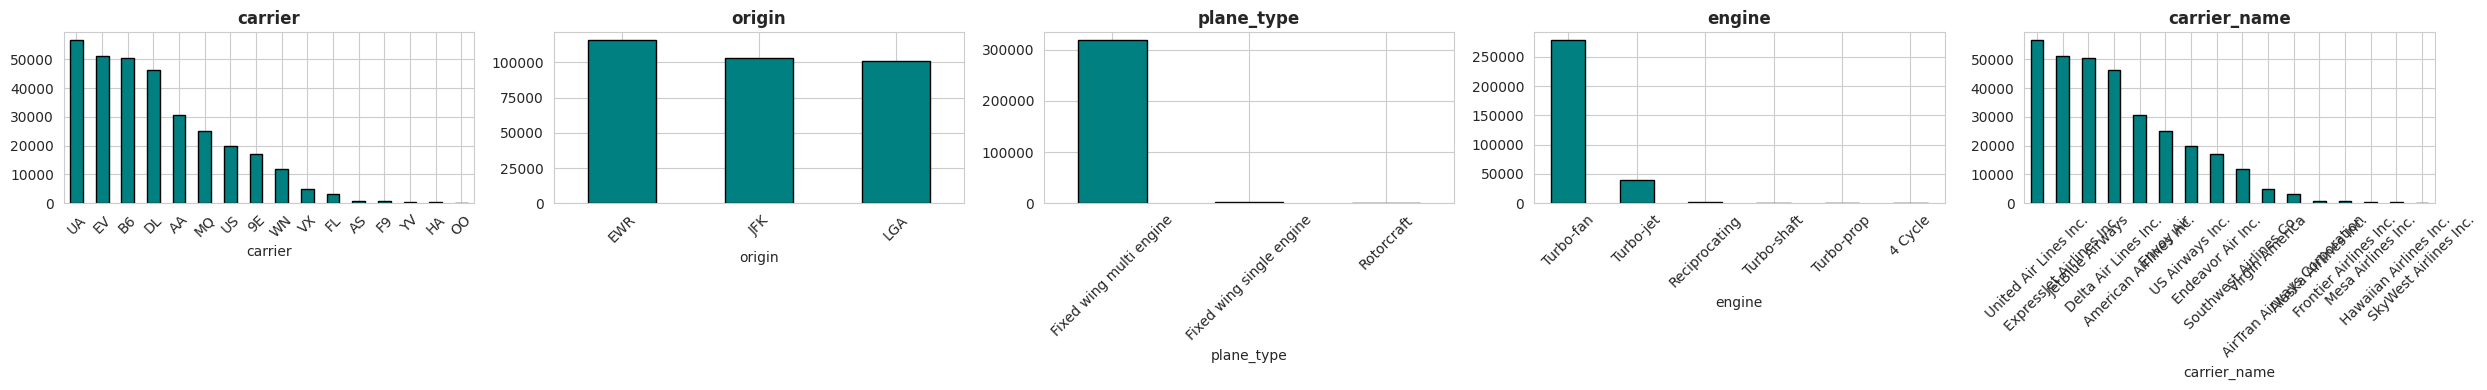

In [29]:
# Count plots for low-cardinality categoricals
low_card_cats = [c for c in cat_cols if df_clean[c].nunique() <= 20]
if low_card_cats:
    fig, axes = plt.subplots(1, len(low_card_cats), figsize=(5*len(low_card_cats), 4))
    if len(low_card_cats) == 1: axes = [axes]
    for ax, c in zip(axes, low_card_cats):
        df_clean[c].value_counts().plot(kind='bar', ax=ax, color='teal', edgecolor='black')
        ax.set_title(c); ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()

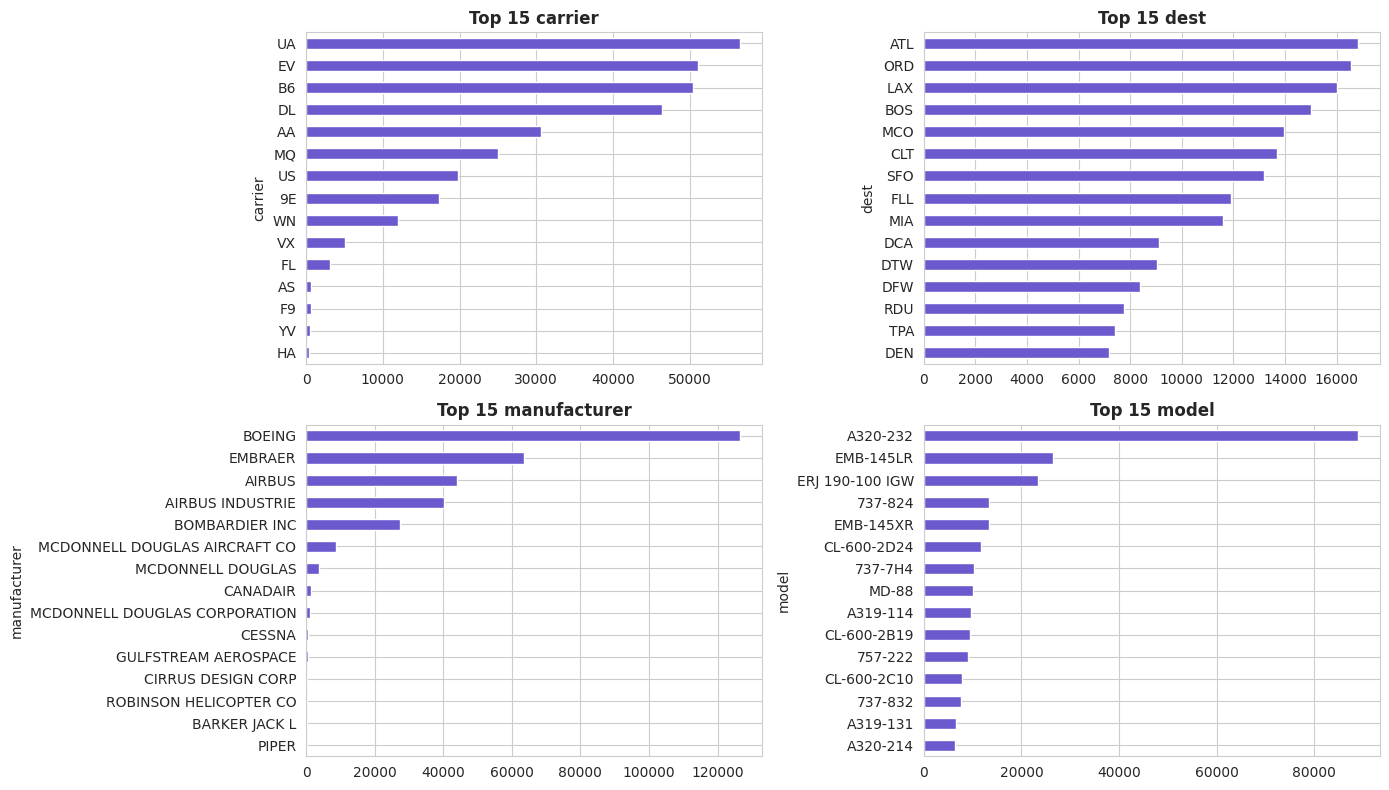

In [30]:
# High-cardinality: carrier, dest, manufacturer, model — top-N bars
high_card = ['carrier', 'dest', 'manufacturer', 'model']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, c in zip(axes.flat, high_card):
    df_clean[c].value_counts().head(15).plot(kind='barh', ax=ax, color='slateblue')
    ax.set_title(f'Top 15 {c}'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

### 7.5 Time distributions (month, day-of-month, hour-of-day)

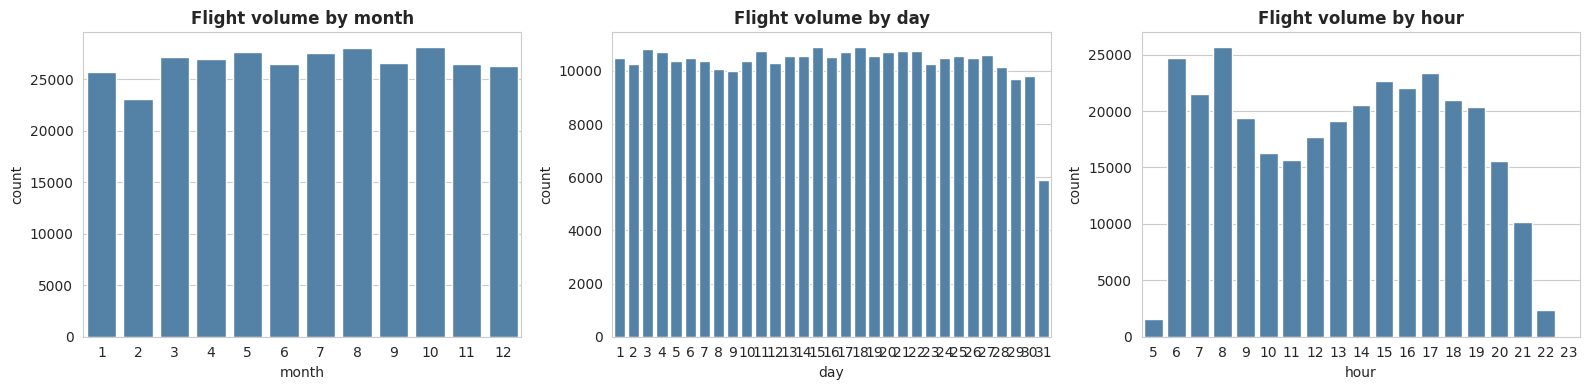

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ['month','day','hour']):
    sns.countplot(x=c, data=df_clean, ax=ax, color='steelblue')
    ax.set_title(f'Flight volume by {c}')
plt.tight_layout(); plt.show()

## Section 8 — Bivariate analysis

Each predictor is now paired with the target (`is_delayed`). This tells us whether — and in which direction — a feature discriminates between on-time and delayed flights.

### 8.1 Numeric predictor vs target — boxplot grid

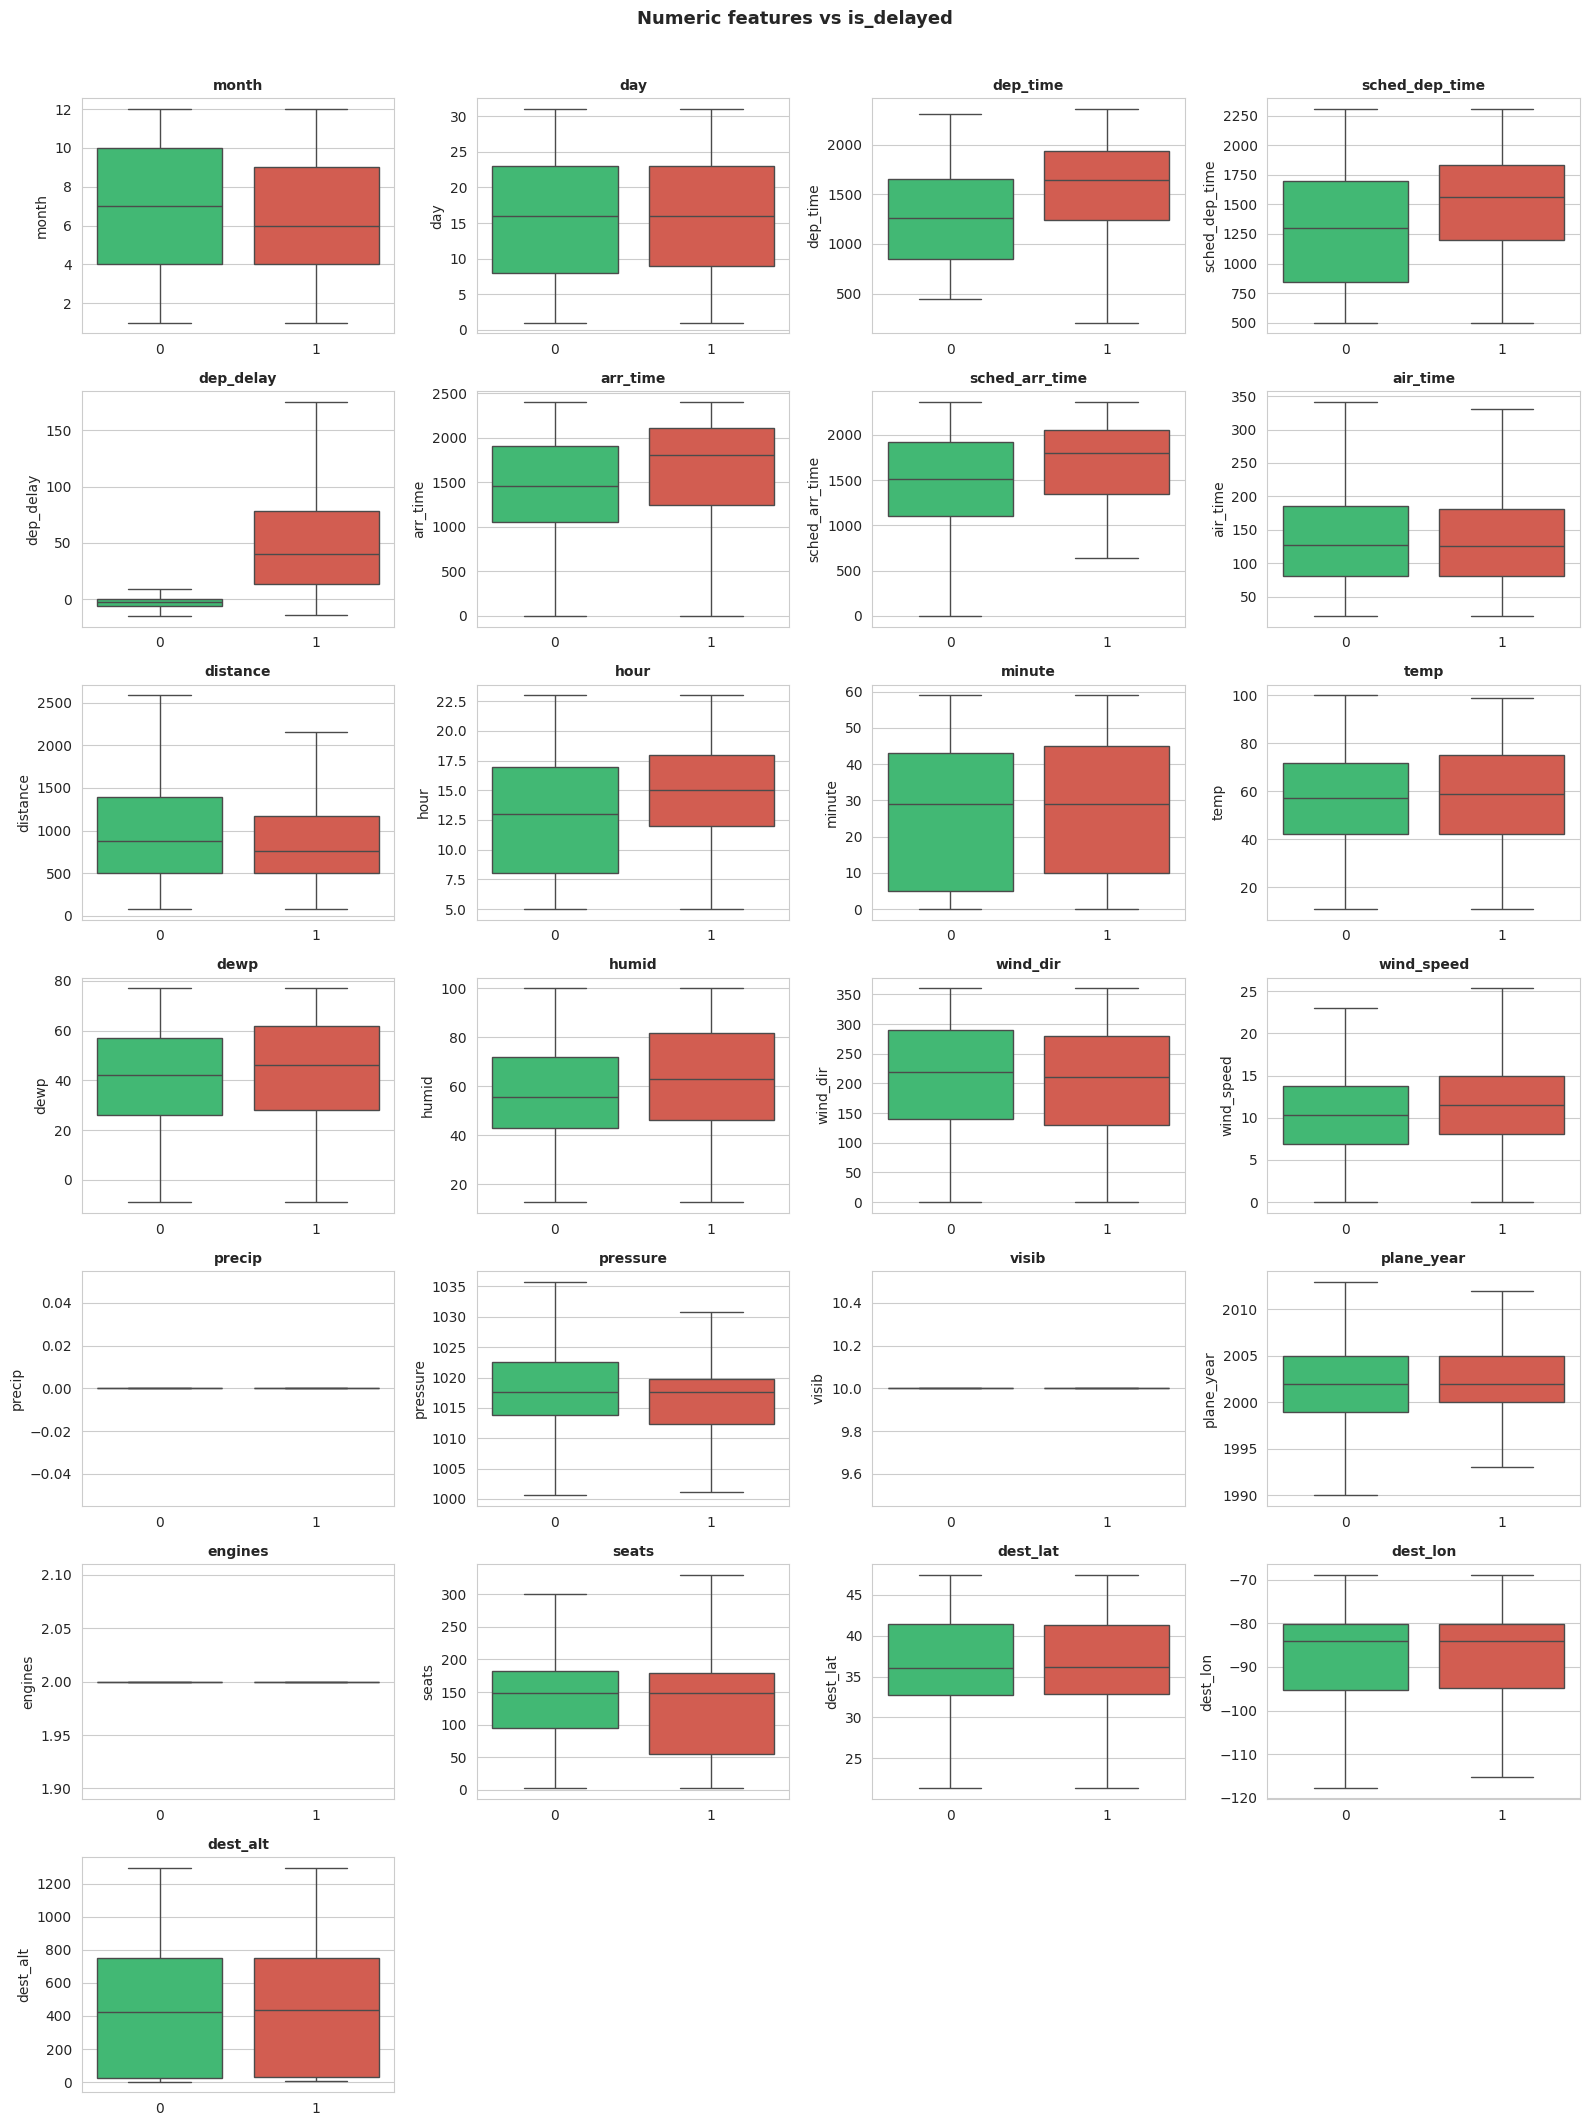

In [32]:
# Sample for speed (boxplots on 300k rows are slow)
sample = df_clean.sample(50000, random_state=RANDOM_SEED)

n = len(predictors_num)
ncols, nrows = 4, int(np.ceil(n/4))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
for i, col in enumerate(predictors_num):
    ax = axes.flat[i]
    sns.boxplot(x='is_delayed', y=col, data=sample, ax=ax,
                palette=['#2ecc71','#e74c3c'], showfliers=False)
    ax.set_title(col, fontsize=10); ax.set_xlabel('')
for j in range(i+1, nrows*ncols):
    axes.flat[j].axis('off')
plt.suptitle('Numeric features vs is_delayed', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 8.2 Delay rate by categorical feature

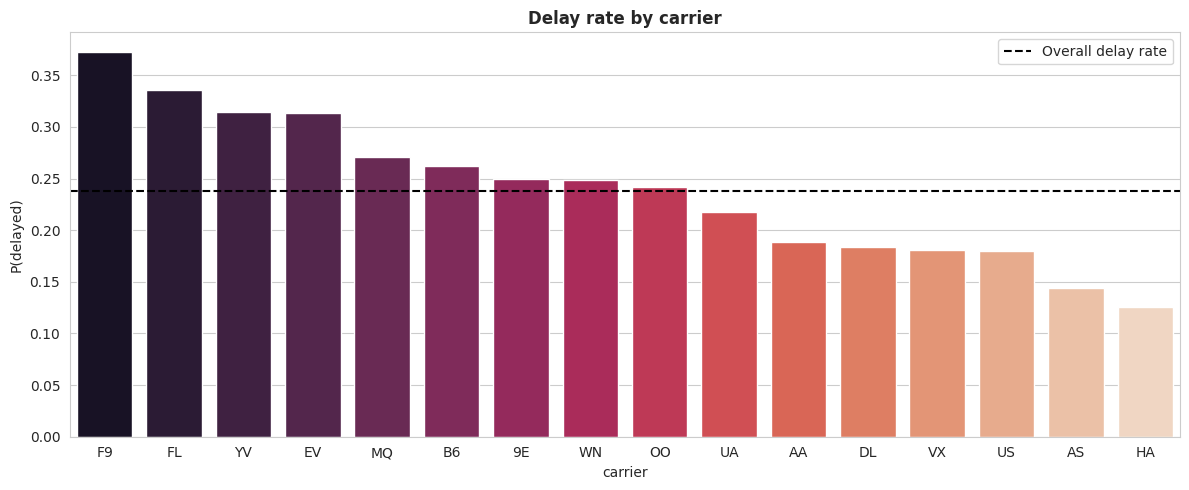

,delay_rate,n_flights
carrier,,
F9,0.372981,681
FL,0.335433,3175
YV,0.314338,544
EV,0.313610,51108
MQ,0.270679,25037
B6,0.262418,50389
9E,0.249162,17294
WN,0.248589,12044
OO,0.241379,29


In [33]:
# Delay rate by carrier
delay_by_carrier = df_clean.groupby('carrier')['is_delayed'].agg(['mean','count']).sort_values('mean', ascending=False)
delay_by_carrier.columns = ['delay_rate', 'n_flights']

fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(x=delay_by_carrier.index, y=delay_by_carrier['delay_rate'],
            palette='rocket', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='black', label='Overall delay rate')
ax.set_title('Delay rate by carrier'); ax.set_ylabel('P(delayed)')
ax.legend(); plt.tight_layout(); plt.show()
delay_by_carrier

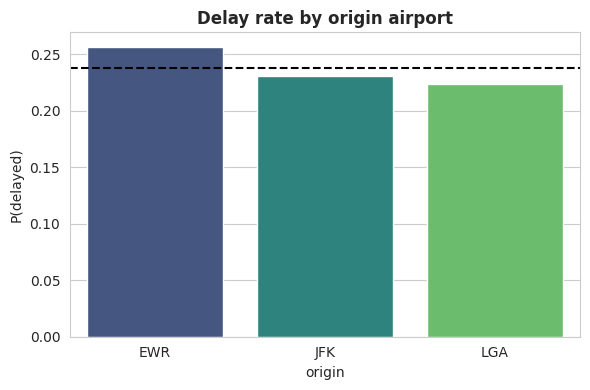

In [34]:
# Delay rate by origin airport
delay_by_origin = df_clean.groupby('origin')['is_delayed'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=delay_by_origin.index, y=delay_by_origin.values, palette='viridis', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='black')
ax.set_title('Delay rate by origin airport'); ax.set_ylabel('P(delayed)')
plt.tight_layout(); plt.show()

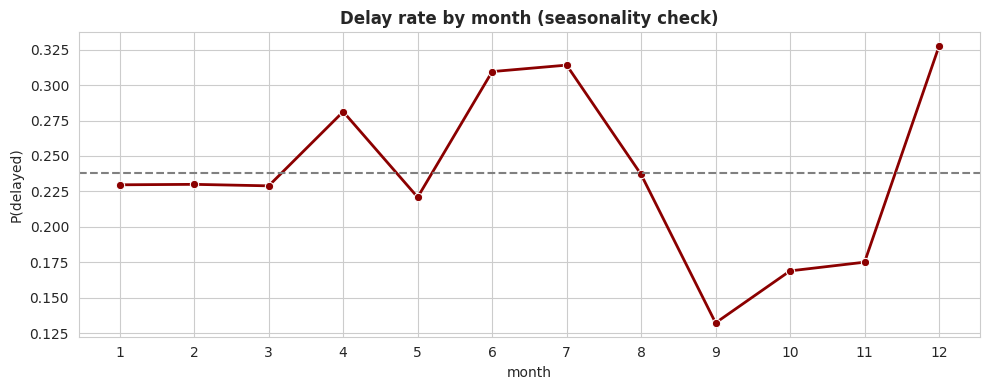

In [35]:
# Delay rate by month
delay_by_month = df_clean.groupby('month')['is_delayed'].mean()
fig, ax = plt.subplots(figsize=(10,4))
sns.lineplot(x=delay_by_month.index, y=delay_by_month.values, marker='o',
             linewidth=2, color='darkred', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='grey')
ax.set_title('Delay rate by month (seasonality check)')
ax.set_xticks(range(1,13)); ax.set_ylabel('P(delayed)')
plt.tight_layout(); plt.show()

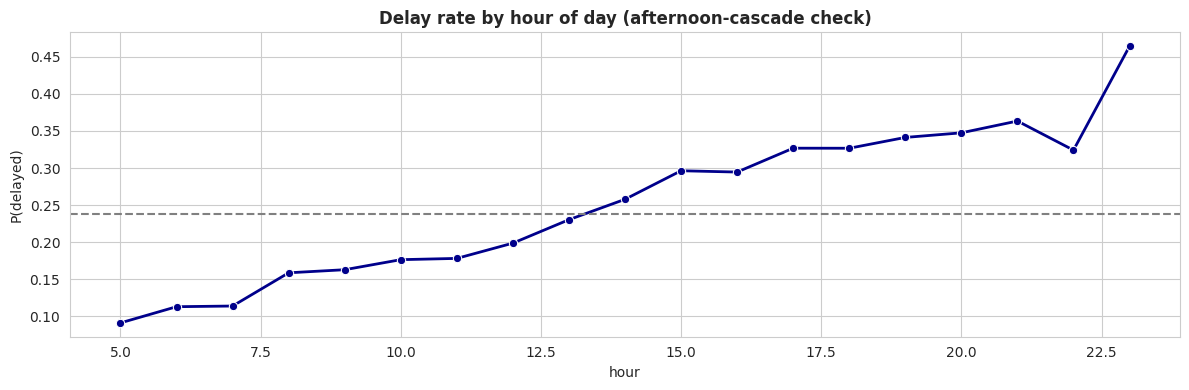

In [36]:
# Delay rate by hour of day — captures the 'afternoon cascade'
delay_by_hour = df_clean.groupby('hour')['is_delayed'].mean()
fig, ax = plt.subplots(figsize=(12,4))
sns.lineplot(x=delay_by_hour.index, y=delay_by_hour.values, marker='o',
             linewidth=2, color='darkblue', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='grey')
ax.set_title('Delay rate by hour of day (afternoon-cascade check)')
ax.set_ylabel('P(delayed)')
plt.tight_layout(); plt.show()

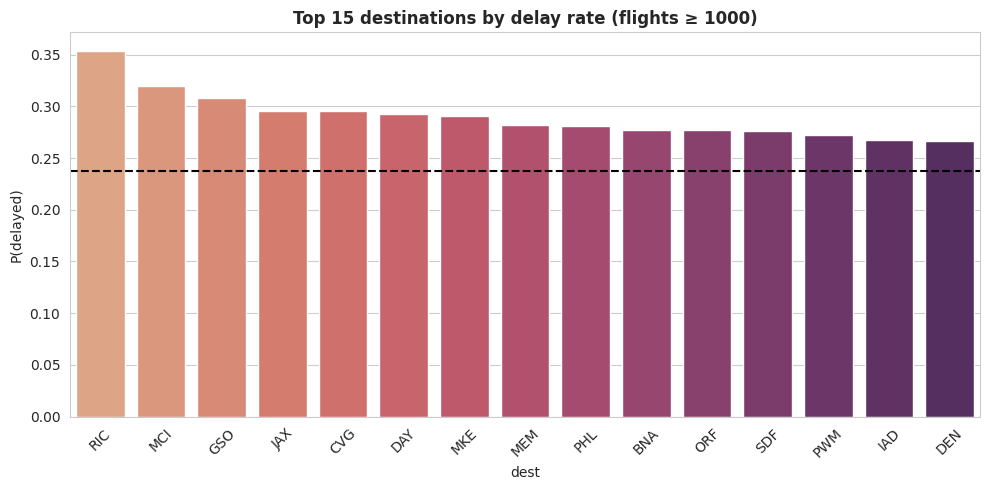

In [37]:
# Top 15 destinations by delay rate (min 1000 flights for reliability)
dest_stats = df_clean.groupby('dest')['is_delayed'].agg(['mean','count'])
dest_stats = dest_stats[dest_stats['count'] >= 1000].sort_values('mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=dest_stats.index, y=dest_stats['mean'], palette='flare', ax=ax)
ax.axhline(df_clean['is_delayed'].mean(), ls='--', c='black')
ax.set_title('Top 15 destinations by delay rate (flights ≥ 1000)')
ax.set_ylabel('P(delayed)'); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

### 8.3 Statistical tests — is each feature related to the target?

In [38]:
# Welch's t-test for each numeric predictor: on-time vs delayed mean
ttest_results = []
for c in predictors_num:
    g0 = df_clean.loc[df_clean['is_delayed']==0, c]
    g1 = df_clean.loc[df_clean['is_delayed']==1, c]
    t, p = stats.ttest_ind(g0, g1, equal_var=False)
    ttest_results.append({'feature': c, 't_stat': t, 'p_value': p,
                          'mean_ontime': g0.mean(), 'mean_delayed': g1.mean()})

ttest_df = pd.DataFrame(ttest_results).sort_values('p_value').reset_index(drop=True)
ttest_df['significant_α=0.01'] = ttest_df['p_value'] < 0.01
ttest_df.round(4)

,feature,t_stat,p_value,mean_ontime,mean_delayed,significant_α=0.01
0,sched_dep_time,-117.1213,0.0000,1290.0355,1502.4123,True
1,dep_time,-145.1716,0.0000,1283.9689,1569.0977,True
2,arr_time,-47.0282,0.0000,1482.9659,1601.6191,True
3,dep_delay,-245.6340,0.0000,-0.9837,56.2190,True
4,sched_arr_time,-92.1037,0.0000,1498.5690,1683.4693,True
5,humid,-68.3970,0.0000,57.6812,63.4587,True
6,dewp,-38.8307,0.0000,40.7418,43.9236,True
7,hour,-116.4164,0.0000,12.6432,14.7524,True
8,pressure,59.4793,0.0000,1018.2646,1016.5565,True
9,visib,60.5985,0.0000,9.4369,8.8435,True


In [39]:
# Chi-square for each categorical predictor vs target
chi_results = []
for c in cat_cols:
    ct = pd.crosstab(df_clean[c], df_clean['is_delayed'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    chi_results.append({'feature': c, 'chi2': chi2, 'p_value': p, 'dof': dof})

chi_df = pd.DataFrame(chi_results).sort_values('p_value').reset_index(drop=True)
chi_df['significant_α=0.01'] = chi_df['p_value'] < 0.01
chi_df.round(4)

,feature,chi2,p_value,dof,significant_α=0.01
0,carrier,4015.8079,0.0000,15,True
1,dest,2536.3983,0.0000,99,True
2,model,3785.2584,0.0000,126,True
3,manufacturer,1620.1253,0.0000,34,True
4,carrier_name,4015.8079,0.0000,15,True
5,origin,369.3191,0.0000,2,True
6,engine,169.8772,0.0000,5,True
7,plane_type,0.1674,0.9197,2,False


**Reading these tables:** at α = 0.01, every numeric and categorical feature is statistically significant — but that's partly an artefact of the 300k+ sample size (with enough data, trivial effects become 'significant'). Effect size matters more than p-value, so we pair these with correlation magnitudes in Section 11.

## Section 9 — Multivariate analysis

We now look at relationships between multiple variables simultaneously — correlation structure, pairwise scatter behaviour, and interaction effects.

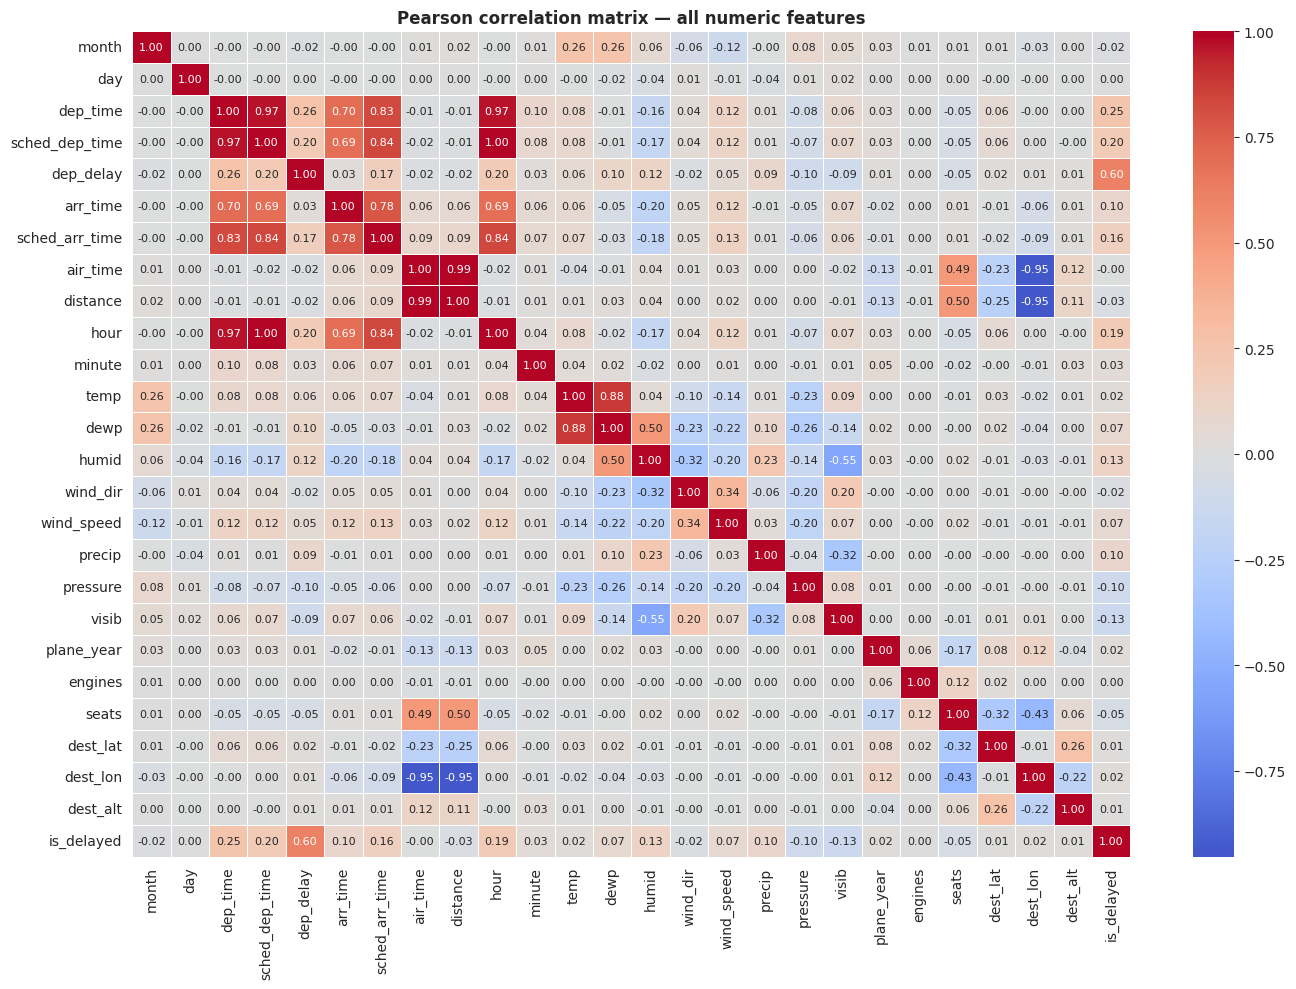

In [40]:
# Correlation heatmap — all numeric columns (including target)
corr = df_clean[num_cols].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=.4, annot_kws={'size':8})
plt.title('Pearson correlation matrix — all numeric features')
plt.tight_layout(); plt.show()

Pairplot features: ['dep_delay', 'dep_time', 'sched_dep_time', 'hour', 'sched_arr_time', 'is_delayed']


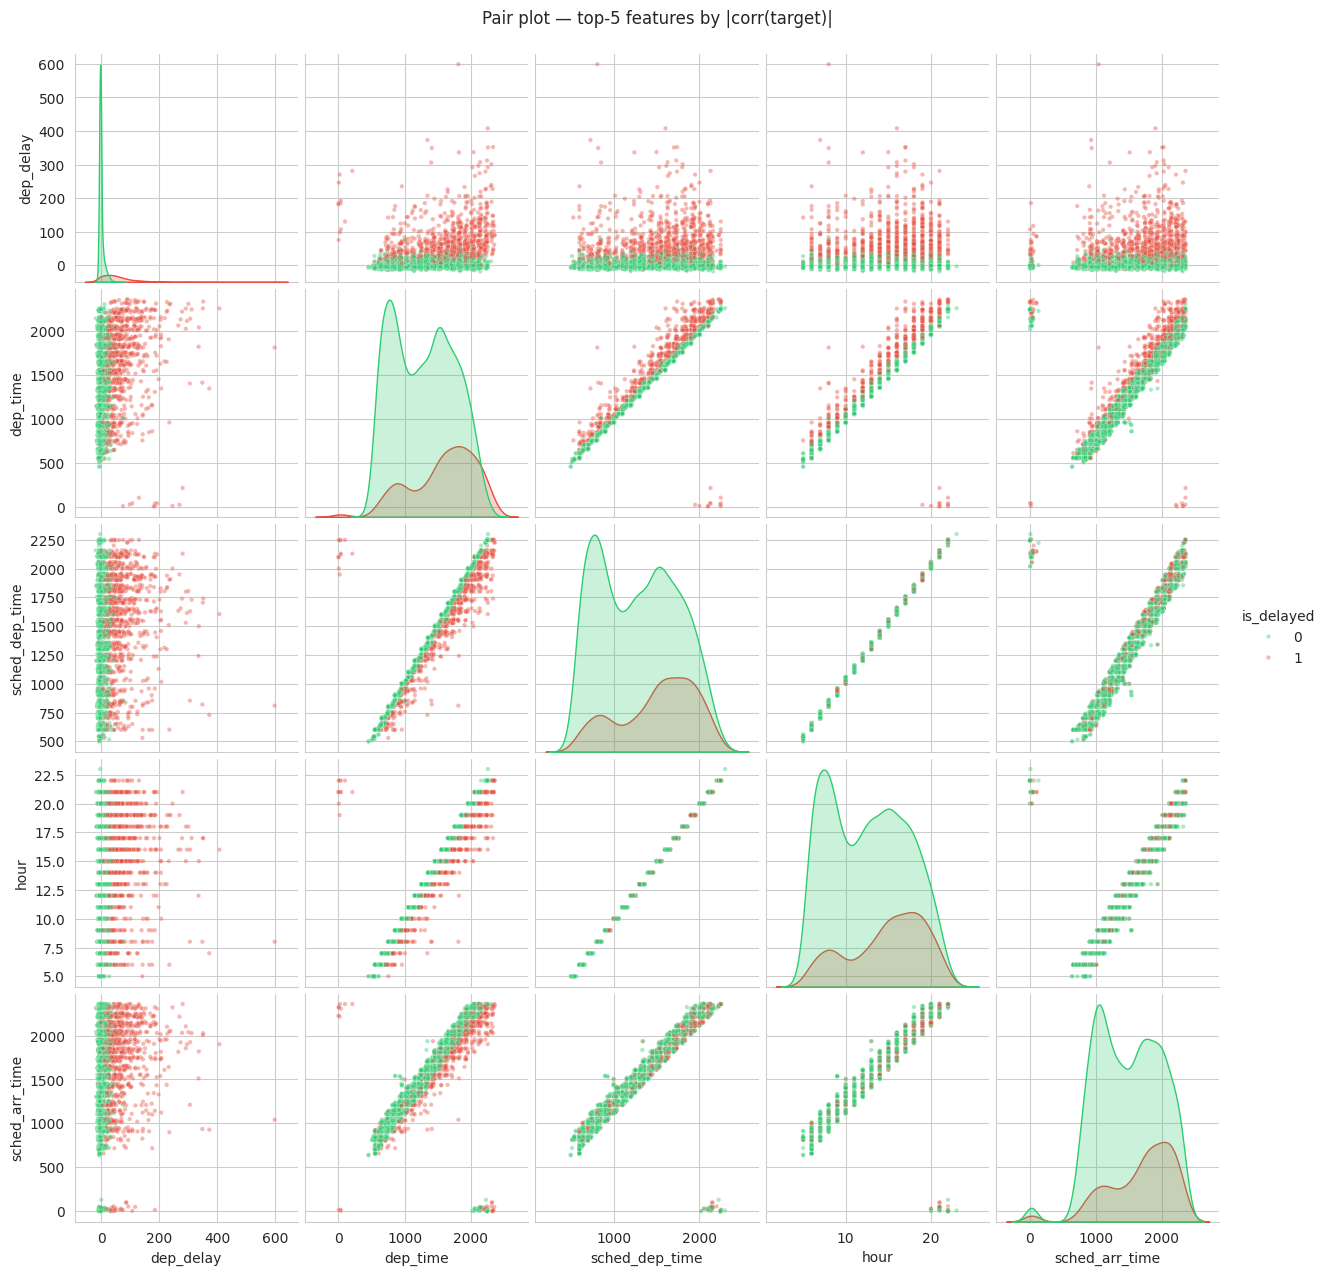

In [41]:
# Pair plot — the top handful of features most correlated with the target
top_corr_target = corr['is_delayed'].abs().sort_values(ascending=False).head(7).index.tolist()
top_corr_target = [c for c in top_corr_target if c != 'is_delayed'][:5] + ['is_delayed']
print('Pairplot features:', top_corr_target)

sns.pairplot(df_clean[top_corr_target].sample(5000, random_state=RANDOM_SEED),
             hue='is_delayed', palette={0:'#2ecc71', 1:'#e74c3c'},
             diag_kind='kde', plot_kws={'alpha':0.4, 's':10})
plt.suptitle('Pair plot — top-5 features by |corr(target)|', y=1.02)
plt.show()

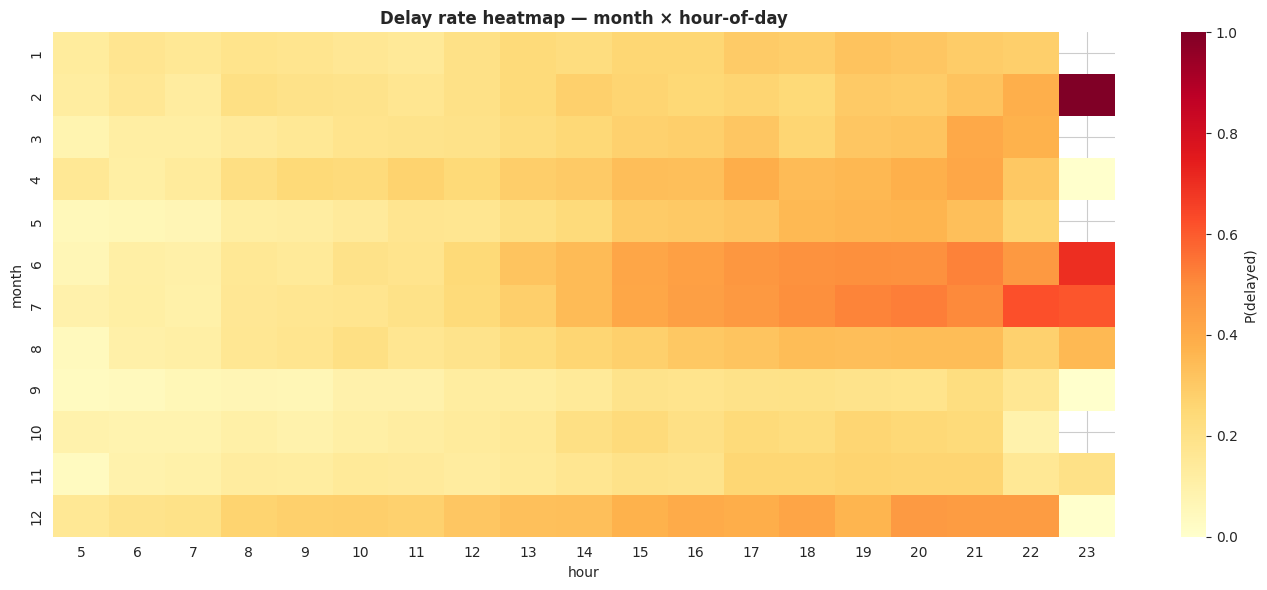

In [42]:
# Delay rate heatmap: month × hour — exposes compound time effects
heat = df_clean.pivot_table(index='month', columns='hour',
                            values='is_delayed', aggfunc='mean')
plt.figure(figsize=(14,6))
sns.heatmap(heat, cmap='YlOrRd', annot=False, cbar_kws={'label':'P(delayed)'})
plt.title('Delay rate heatmap — month × hour-of-day')
plt.tight_layout(); plt.show()

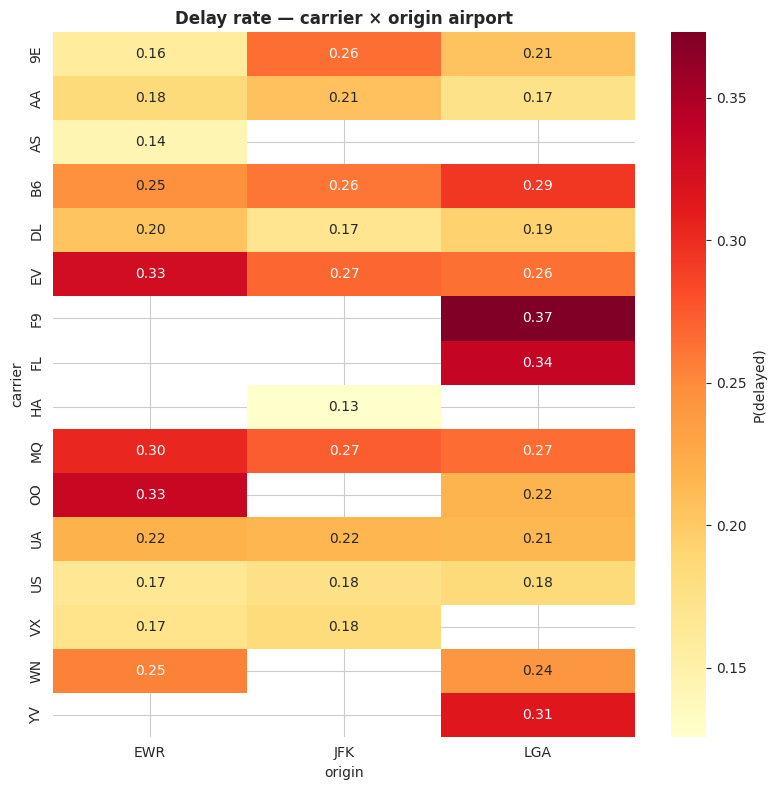

In [43]:
# Carrier × origin delay rate — operational interaction
heat2 = df_clean.pivot_table(index='carrier', columns='origin',
                              values='is_delayed', aggfunc='mean')
plt.figure(figsize=(8,8))
sns.heatmap(heat2, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label':'P(delayed)'})
plt.title('Delay rate — carrier × origin airport')
plt.tight_layout(); plt.show()

## Section 10 — Multicollinearity analysis

This is the **collinearity step** asked for in the brief. Two distinct things are being handled here and they must not be confused:

- **Multicollinearity** — relationship *between predictors*. Measured by (a) pairwise correlation and (b) **Variance Inflation Factor (VIF)**. Two highly-correlated predictors carry redundant information; in linear models this inflates coefficient variance and destabilises the fit. For tree-based models it's less fatal but still hurts interpretability.
- **Feature-target correlation** — how predictive a single feature is of the target. Handled in Section 11.

**Drop rules used here:**
1. `|corr|` between any two predictors > **0.85** → drop the one that has weaker correlation with the target.
2. **VIF > 10** → drop iteratively until no feature exceeds the threshold.

In [44]:
# 10.1 Highly-correlated predictor pairs
corr_pred = df_clean[predictors_num].corr().abs()
upper = corr_pred.where(np.triu(np.ones(corr_pred.shape), k=1).astype(bool))

pairs = (upper.stack()
              .reset_index()
              .rename(columns={'level_0':'feat_a','level_1':'feat_b', 0:'abs_corr'})
              .query('abs_corr > 0.70')
              .sort_values('abs_corr', ascending=False))
pairs.round(3)

,feat_a,feat_b,abs_corr
84,sched_dep_time,hour,0.999
183,air_time,distance,0.991
53,dep_time,sched_dep_time,0.968
59,dep_time,hour,0.966
223,distance,dest_lon,0.953
198,air_time,dest_lon,0.950
287,temp,dewp,0.882
81,sched_dep_time,sched_arr_time,0.837
159,sched_arr_time,hour,0.836
56,dep_time,sched_arr_time,0.827


In [45]:
# For each high-correlation pair (|corr|>0.85), keep the feature with stronger |corr(target)|
target_corr = df_clean[predictors_num + ['is_delayed']].corr()['is_delayed'].abs()
high_corr_pairs = pairs[pairs['abs_corr'] > 0.85]

drop_due_collinearity = set()
for _, row in high_corr_pairs.iterrows():
    a, b = row['feat_a'], row['feat_b']
    if a in drop_due_collinearity or b in drop_due_collinearity:
        continue
    weaker = a if target_corr[a] < target_corr[b] else b
    drop_due_collinearity.add(weaker)

print('Drop due to pairwise collinearity (|r|>0.85):', drop_due_collinearity)

Drop due to pairwise collinearity (|r|>0.85): {'dest_lon', 'hour', 'temp', 'sched_dep_time', 'air_time'}


In [46]:
# 10.2 Variance Inflation Factor
def compute_vif(frame):
    frame = frame.copy()
    frame = frame.assign(_const=1.0)  # statsmodels needs a constant
    vif_rows = []
    for i, col in enumerate(frame.columns):
        if col == '_const': continue
        try:
            v = variance_inflation_factor(frame.values, i)
        except Exception:
            v = np.inf
        vif_rows.append({'feature': col, 'VIF': v})
    return pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)

kept_predictors = [c for c in predictors_num if c not in drop_due_collinearity]
vif_before = compute_vif(df_clean[kept_predictors])
vif_before.round(2)

,feature,VIF
5,sched_arr_time,4.44
2,dep_time,3.59
4,arr_time,2.78
9,humid,2.12
8,dewp,1.67
14,visib,1.58
17,seats,1.49
6,distance,1.42
10,wind_dir,1.31
13,pressure,1.27


In [47]:
# Iteratively drop the highest-VIF feature until all VIF < 10
VIF_THRESHOLD = 10.0
kept = kept_predictors.copy()
iteratively_dropped = []

while True:
    vif_tbl = compute_vif(df_clean[kept])
    worst = vif_tbl.iloc[0]
    if worst['VIF'] < VIF_THRESHOLD:
        break
    kept.remove(worst['feature'])
    iteratively_dropped.append((worst['feature'], round(worst['VIF'], 2)))

print('Iteratively dropped (feature, VIF at drop time):')
for f, v in iteratively_dropped: print(f'  {f:20s} VIF={v}')

vif_after = compute_vif(df_clean[kept])
print('\nFinal VIFs:')
print(vif_after.round(2).to_string(index=False))

Iteratively dropped (feature, VIF at drop time):



Final VIFs:
       feature  VIF
sched_arr_time 4.44
      dep_time 3.59
      arr_time 2.78
         humid 2.12
          dewp 1.67
         visib 1.58
         seats 1.49
      distance 1.42
      wind_dir 1.31
      pressure 1.27
      dest_lat 1.26
    wind_speed 1.24
     dep_delay 1.17
        precip 1.13
      dest_alt 1.13
         month 1.11
    plane_year 1.05
       engines 1.03
        minute 1.02
           day 1.00


In [48]:
# Final set after multicollinearity handling
dropped_multi = list(drop_due_collinearity) + [f for f,_ in iteratively_dropped]
surviving_num = [c for c in predictors_num if c not in dropped_multi]

print('Numeric predictors dropped for multicollinearity:', dropped_multi)
print(f'Surviving numeric predictors: {len(surviving_num)}')
print(surviving_num)

Numeric predictors dropped for multicollinearity: ['dest_lon', 'hour', 'temp', 'sched_dep_time', 'air_time']
Surviving numeric predictors: 20
['month', 'day', 'dep_time', 'dep_delay', 'arr_time', 'sched_arr_time', 'distance', 'minute', 'dewp', 'humid', 'wind_dir', 'wind_speed', 'precip', 'pressure', 'visib', 'plane_year', 'engines', 'seats', 'dest_lat', 'dest_alt']


## Section 11 — Feature-target signal & low-signal drop

This is the *other* half of the brief's "drop features with low correlation to target" ask. Two complementary signals:
- **Point-biserial correlation** (since target is binary) for numeric features
- **Mutual information** for all features — captures non-linear dependence

In [49]:
# Point-biserial correlation (equivalent to Pearson for a binary target)
pb_corr = {}
for c in surviving_num:
    r, _ = stats.pointbiserialr(df_clean['is_delayed'], df_clean[c])
    pb_corr[c] = r
pb_tbl = pd.Series(pb_corr).abs().sort_values(ascending=False).to_frame('|corr_target|')
pb_tbl

,|corr_target|
dep_delay,0.604868
dep_time,0.251213
sched_arr_time,0.160637
visib,0.128244
humid,0.126125
pressure,0.103933
precip,0.098633
arr_time,0.095865
dewp,0.070313
wind_speed,0.067198


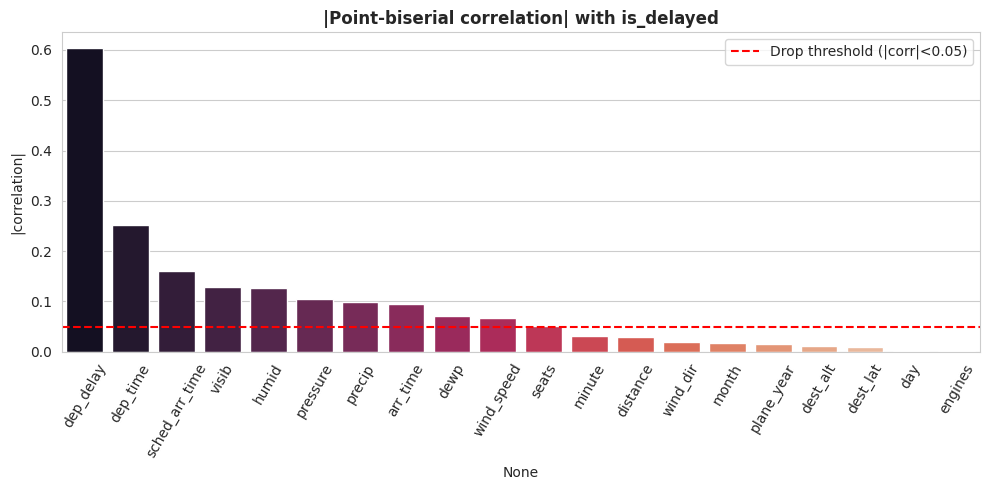

In [50]:
# Visualise
plt.figure(figsize=(10,5))
sns.barplot(x=pb_tbl.index, y=pb_tbl['|corr_target|'], palette='rocket')
plt.axhline(0.05, ls='--', c='red',
            label='Drop threshold (|corr|<0.05)')
plt.title('|Point-biserial correlation| with is_delayed')
plt.xticks(rotation=60); plt.ylabel('|correlation|')
plt.legend(); plt.tight_layout(); plt.show()

In [51]:
# Mutual information (captures non-linear signal that correlation misses)
# Encode categoricals with simple ordinal coding for MI
mi_df = df_clean.copy()
for c in cat_cols:
    mi_df[c] = mi_df[c].astype('category').cat.codes

mi_features = surviving_num + cat_cols
mi_scores = mutual_info_classif(mi_df[mi_features], mi_df['is_delayed'],
                                random_state=RANDOM_SEED)
mi_tbl = pd.Series(mi_scores, index=mi_features).sort_values(ascending=False).to_frame('MI')
mi_tbl.round(4)

,MI
dep_delay,0.2716
arr_time,0.0556
dep_time,0.0520
visib,0.0501
engines,0.0452
engine,0.0363
humid,0.0330
sched_arr_time,0.0221
origin,0.0184
pressure,0.0183


In [52]:
# Drop features that fail BOTH a correlation and a mutual-information test
# (using AND so we don't drop features that have non-linear signal invisible to Pearson)
# Thresholds calibrated to the observed value distribution above:
CORR_THRESH = 0.02   # |point-biserial correlation with target| must exceed this
MI_THRESH   = 0.01   # mutual information with target must exceed this

drop_low_signal = []
for f in surviving_num:
    corr_weak = abs(pb_corr[f]) < CORR_THRESH
    mi_weak   = mi_tbl.loc[f, 'MI'] < MI_THRESH
    if corr_weak and mi_weak:
        drop_low_signal.append(f)

print(f'Drop rule: |corr|<{CORR_THRESH}  AND  MI<{MI_THRESH}')
print(f'Numeric features dropped for low target signal: {drop_low_signal}')
final_num_predictors = [c for c in surviving_num if c not in drop_low_signal]
print(f'Final numeric predictors ({len(final_num_predictors)}):')
print(final_num_predictors)

Drop rule: |corr|<0.02  AND  MI<0.01
Numeric features dropped for low target signal: ['day', 'wind_dir', 'plane_year', 'dest_lat', 'dest_alt']
Final numeric predictors (15):
['month', 'dep_time', 'dep_delay', 'arr_time', 'sched_arr_time', 'distance', 'minute', 'dewp', 'humid', 'wind_speed', 'precip', 'pressure', 'visib', 'engines', 'seats']


In [53]:
# Build the final cleaned dataframe
final_features = final_num_predictors + cat_cols + ['is_delayed']
df_final = df_clean[final_features].copy()
print('Final shape:', df_final.shape)
print('Dropped overall:',
      set(df_clean.columns) - set(df_final.columns) - {'arr_delay'})
df_final.head()

Final shape: (319809, 24)
Dropped overall: {'day', 'plane_year', 'wind_dir', 'hour', 'dest_lon', 'temp', 'dest_lat', 'sched_dep_time', 'dest_alt', 'air_time'}


,month,dep_time,dep_delay,arr_time,sched_arr_time,distance,minute,dewp,humid,wind_speed,precip,pressure,visib,engines,seats,carrier,origin,dest,plane_type,manufacturer,model,engine,carrier_name,is_delayed
0,1,517.0,2.0,830.0,819,1400,15,28.04,64.43,12.65858,0.0,1011.9,10.0,2.0,149.0,UA,EWR,IAH,Fixed wing multi engine,BOEING,737-824,Turbo-fan,United Air Lines Inc.,0
1,1,533.0,4.0,850.0,830,1416,29,24.98,54.81,14.96014,0.0,1011.4,10.0,2.0,149.0,UA,LGA,IAH,Fixed wing multi engine,BOEING,737-824,Turbo-fan,United Air Lines Inc.,1
2,1,542.0,2.0,923.0,850,1089,40,26.96,61.63,14.96014,0.0,1012.1,10.0,2.0,178.0,AA,JFK,MIA,Fixed wing multi engine,BOEING,757-223,Turbo-fan,American Airlines Inc.,1
4,1,554.0,-6.0,812.0,837,762,0,24.98,54.81,16.11092,0.0,1011.7,10.0,2.0,178.0,DL,LGA,ATL,Fixed wing multi engine,BOEING,757-232,Turbo-fan,Delta Air Lines Inc.,0
5,1,554.0,-4.0,740.0,728,719,58,28.04,64.43,12.65858,0.0,1011.9,10.0,2.0,191.0,UA,EWR,ORD,Fixed wing multi engine,BOEING,737-924ER,Turbo-fan,United Air Lines Inc.,0


## Section 12 — Outlier detection and handling

Two complementary detectors:
- **IQR method** — any point outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. Robust, distribution-free.
- **Z-score method** — any point with `|z| > 3`. Assumes near-normality but fast.

**Handling strategy:** **winsorise** at the 1st and 99th percentile rather than drop. Dropping 5-10 % of 330 k rows is fine; but the tails in delay data often *are* the signal (catastrophic weather events). Winsorisation keeps the rows but caps the extreme values so they don't dominate variance in downstream linear models.

In [54]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (s < lo) | (s > hi)
    return mask.sum(), lo, hi

def z_outliers(s, thr=3):
    z = np.abs(zscore(s, nan_policy='omit'))
    return (z > thr).sum()

outlier_tbl = pd.DataFrame({
    f: {
        'IQR_outliers':   iqr_outliers(df_final[f])[0],
        'Z_outliers':     z_outliers(df_final[f]),
        'pct_IQR':        iqr_outliers(df_final[f])[0] / len(df_final) * 100,
    } for f in final_num_predictors
}).T.round(2)
outlier_tbl.sort_values('pct_IQR', ascending=False)

,IQR_outliers,Z_outliers,pct_IQR
visib,51594.0,14899.0,16.13
dep_delay,42069.0,7724.0,13.15
precip,20480.0,3931.0,6.40
wind_speed,7588.0,2791.0,2.37
pressure,7159.0,888.0,2.24
seats,3233.0,3233.0,1.01
engines,1985.0,1985.0,0.62
distance,709.0,709.0,0.22
minute,0.0,0.0,0.00
arr_time,0.0,0.0,0.00


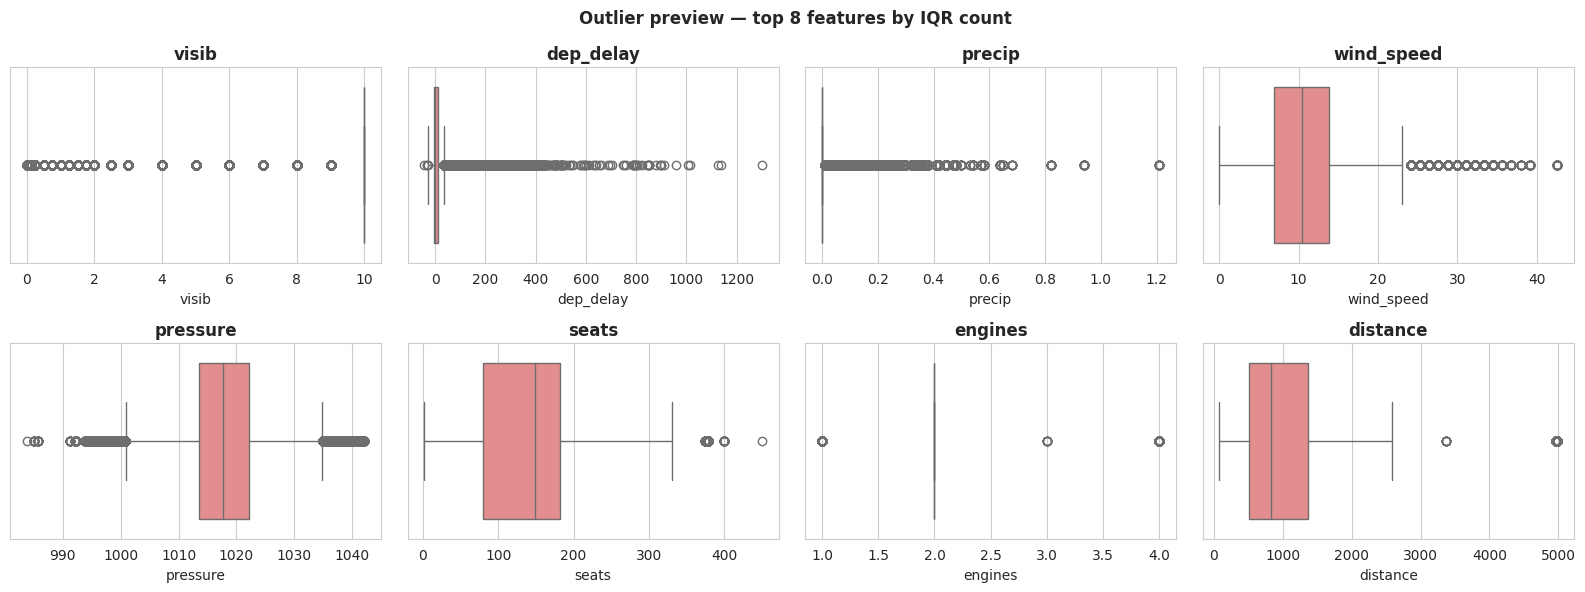

In [55]:
# Visual: boxplots of the top 8 numeric features by outlier count
top_outlier_feats = outlier_tbl.sort_values('pct_IQR', ascending=False).head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16,6))
for ax, f in zip(axes.flat, top_outlier_feats):
    sns.boxplot(x=df_final[f], ax=ax, color='lightcoral')
    ax.set_title(f)
plt.suptitle('Outlier preview — top 8 features by IQR count', fontweight='bold')
plt.tight_layout(); plt.show()

In [56]:
# Winsorise at 1st / 99th percentile
from scipy.stats.mstats import winsorize

df_wins = df_final.copy()
for f in final_num_predictors:
    df_wins[f] = winsorize(df_wins[f].values, limits=[0.01, 0.01])

# After-state summary
after_tbl = pd.DataFrame({
    f: {'IQR_outliers_after': iqr_outliers(df_wins[f])[0],
        'pct_IQR_after':       iqr_outliers(df_wins[f])[0]/len(df_wins)*100}
    for f in final_num_predictors
}).T.round(2)

compare = outlier_tbl[['IQR_outliers','pct_IQR']].join(after_tbl)
compare.sort_values('pct_IQR', ascending=False).head(12)

,IQR_outliers,pct_IQR,IQR_outliers_after,pct_IQR_after
visib,51594.0,16.13,51594.0,16.13
dep_delay,42069.0,13.15,42065.0,13.15
precip,20480.0,6.40,20480.0,6.40
wind_speed,7588.0,2.37,7588.0,2.37
pressure,7159.0,2.24,4679.0,1.46
seats,3233.0,1.01,3233.0,1.01
engines,1985.0,0.62,0.0,0.00
distance,709.0,0.22,0.0,0.00
minute,0.0,0.00,0.0,0.00
arr_time,0.0,0.00,0.0,0.00


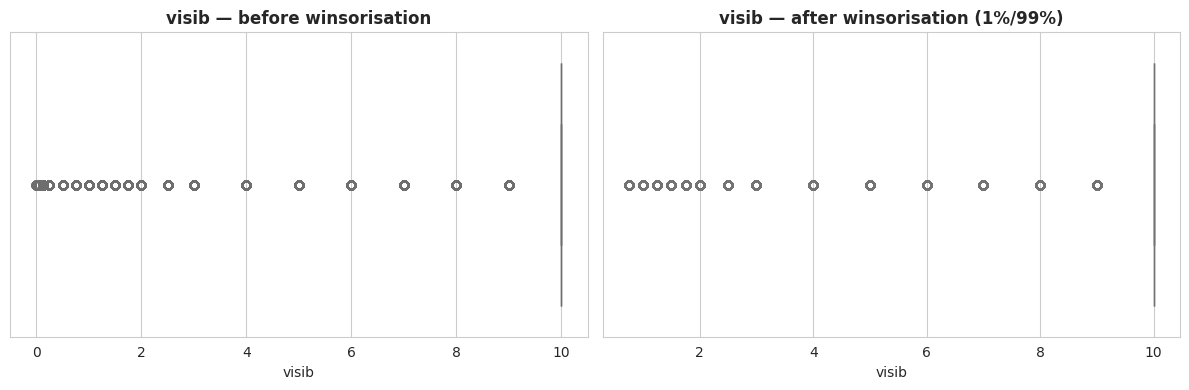

In [57]:
# Visual before vs after for the feature with the most outliers
feat = outlier_tbl.sort_values('pct_IQR', ascending=False).index[0]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_final[feat], ax=ax[0], color='lightcoral'); ax[0].set_title(f'{feat} — before winsorisation')
sns.boxplot(x=df_wins[feat],  ax=ax[1], color='lightgreen'); ax[1].set_title(f'{feat} — after winsorisation (1%/99%)')
plt.tight_layout(); plt.show()

## Section 13 — Transformation & scaling

Two separate concerns:
- **Transformation** tames skewed distributions so linear models and distance-based models don't get dominated by the long tails. We use `log1p` for right-skewed non-negative features and `Yeo-Johnson` for features that include zero or negatives.
- **Scaling** puts all features on the same numeric range so that gradient-based models (logistic regression, SVM, neural nets) and distance-based models (KNN) aren't dominated by features with larger units. Tree-based models (RF, XGBoost, LightGBM) don't need scaling.

In [58]:
# 13.1 Transform highly-skewed features
from sklearn.preprocessing import PowerTransformer

skew_before = df_wins[final_num_predictors].apply(skew).sort_values(key=abs, ascending=False)
to_transform = skew_before[skew_before.abs() > 1.0].index.tolist()
print('Features requiring transformation (|skew|>1):', to_transform)

df_trans = df_wins.copy()
pt = PowerTransformer(method='yeo-johnson')
if to_transform:
    df_trans[to_transform] = pt.fit_transform(df_trans[to_transform])

skew_after = df_trans[final_num_predictors].apply(skew).sort_values(key=abs, ascending=False)

skew_compare = pd.DataFrame({'skew_before': skew_before, 'skew_after': skew_after}).round(3)
skew_compare

Features requiring transformation (|skew|>1): ['precip', 'dep_delay', 'visib']


,skew_before,skew_after
arr_time,-0.455,-0.455
dep_delay,3.063,-0.046
dep_time,-0.005,-0.005
dewp,-0.170,-0.170
distance,0.952,0.952
engines,NaN,NaN
humid,0.177,0.177
minute,0.100,0.100
month,-0.026,-0.026
precip,6.261,3.566


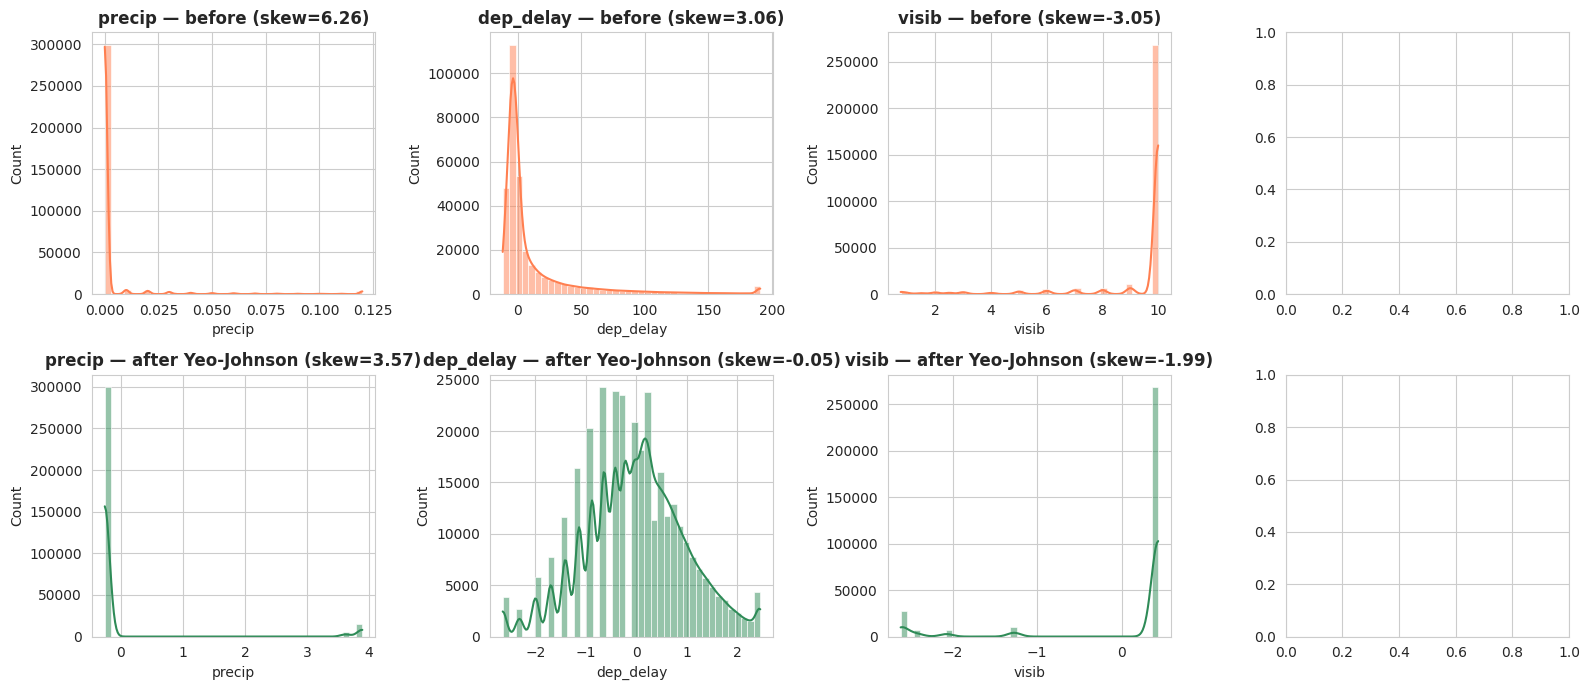

In [59]:
# Visual — before/after for top 4 most-skewed
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, f in enumerate(to_transform[:4]):
    sns.histplot(df_wins[f],  bins=40, kde=True, ax=axes[0,i], color='coral')
    axes[0,i].set_title(f'{f} — before (skew={skew_before[f]:.2f})')
    sns.histplot(df_trans[f], bins=40, kde=True, ax=axes[1,i], color='seagreen')
    axes[1,i].set_title(f'{f} — after Yeo-Johnson (skew={skew_after[f]:.2f})')
plt.tight_layout(); plt.show()

In [60]:
# 13.2 One-hot encode categoricals (keep it compact: high-cardinality → frequency encoding)
df_encoded = df_trans.copy()

# Low-card → one-hot
LOW_CARD = [c for c in cat_cols if df_encoded[c].nunique() <= 20]
df_encoded = pd.get_dummies(df_encoded, columns=LOW_CARD, drop_first=True)

# High-card → frequency encoding (keeps dimensionality in check)
HIGH_CARD = [c for c in cat_cols if c not in LOW_CARD]
for c in HIGH_CARD:
    freq = df_encoded[c].value_counts(normalize=True)
    df_encoded[c + '_freq'] = df_encoded[c].map(freq)
df_encoded = df_encoded.drop(columns=HIGH_CARD)

print('Shape after encoding:', df_encoded.shape)

Shape after encoding: (319809, 58)


In [61]:
# 13.3 Scale numeric columns
numeric_final = [c for c in df_encoded.columns
                  if df_encoded[c].dtype != bool and c != 'is_delayed'
                  and df_encoded[c].dtype in [np.float64, np.int64]]

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_final] = scaler.fit_transform(df_scaled[numeric_final])

print('Post-scaling summary (first 5 numeric features):')
df_scaled[numeric_final[:5]].describe().round(3).T

Post-scaling summary (first 5 numeric features):


,count,mean,std,min,25%,50%,75%,max
month,319809.0,0.0,1.0,-1.632,-0.753,0.126,1.005,1.592
dep_time,319809.0,-0.0,1.0,-1.668,-0.917,0.107,0.816,1.862
dep_delay,319809.0,-0.0,1.0,-2.647,-0.640,-0.052,0.647,2.457
arr_time,319809.0,-0.0,1.0,-2.829,-0.766,0.060,0.820,1.584
sched_arr_time,319809.0,-0.0,1.0,-3.066,-0.854,0.033,0.824,1.654


In [62]:
# Sanity-check: all scaled columns should have mean ≈ 0 and std ≈ 1
# (Zero-variance columns would scale to all-zero — exclude them from the check)
stds = df_scaled[numeric_final].std()
active_cols = stds[stds > 1e-9].index.tolist()
inactive = [c for c in numeric_final if c not in active_cols]

mean_check = df_scaled[active_cols].mean().abs().max()
std_check  = (df_scaled[active_cols].std() - 1).abs().max()
print(f'Active numeric columns           : {len(active_cols)} / {len(numeric_final)}')
if inactive:
    print(f'Zero-variance columns (skipped)  : {inactive}')
print(f'Max |mean| across scaled cols    : {mean_check:.6f}   (should be ~0)')
print(f'Max |std-1| across scaled cols   : {std_check:.6f}   (should be ~0)')

Active numeric columns           : 17 / 18
Zero-variance columns (skipped)  : ['engines']
Max |mean| across scaled cols    : 0.000000   (should be ~0)
Max |std-1| across scaled cols   : 0.000002   (should be ~0)


In [63]:
# Final ML-ready dataset
print(f'Final modelling dataset shape : {df_scaled.shape}')
print(f'Class balance                  : {df_scaled["is_delayed"].mean():.3f}')
df_scaled.head()

Final modelling dataset shape : (319809, 58)
Class balance                  : 0.238


,month,dep_time,dep_delay,arr_time,sched_arr_time,distance,minute,dewp,humid,wind_speed,precip,pressure,visib,engines,seats,is_delayed,carrier_AA,carrier_AS,carrier_B6,carrier_DL,carrier_EV,carrier_F9,carrier_FL,carrier_HA,carrier_MQ,carrier_OO,carrier_UA,carrier_US,carrier_VX,carrier_WN,carrier_YV,origin_JFK,origin_LGA,plane_type_Fixed wing single engine,plane_type_Rotorcraft,engine_Reciprocating,engine_Turbo-fan,engine_Turbo-jet,engine_Turbo-prop,engine_Turbo-shaft,carrier_name_Alaska Airlines Inc.,carrier_name_American Airlines Inc.,carrier_name_Delta Air Lines Inc.,carrier_name_Endeavor Air Inc.,carrier_name_Envoy Air,carrier_name_ExpressJet Airlines Inc.,carrier_name_Frontier Airlines Inc.,carrier_name_Hawaiian Airlines Inc.,carrier_name_JetBlue Airways,carrier_name_Mesa Airlines Inc.,carrier_name_SkyWest Airlines Inc.,carrier_name_Southwest Airlines Co.,carrier_name_US Airways Inc.,carrier_name_United Air Lines Inc.,carrier_name_Virgin America,dest_freq,manufacturer_freq,model_freq
0,-1.632216,-1.668220,0.337644,-1.293861,-1.479498,0.513606,-0.574860,-0.703835,0.277170,0.301284,-0.261463,-0.867070,0.429008,0.0,0.160393,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,-0.307658,1.17076,-0.554671
1,-1.632216,-1.668220,0.428227,-1.255874,-1.457012,0.535851,0.152517,-0.863538,-0.218880,0.726585,-0.261463,-0.939731,0.429008,0.0,0.160393,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,-0.307658,1.17076,-0.554671
2,-1.632216,-1.668220,0.337644,-1.117221,-1.416128,0.081209,0.724027,-0.760201,0.132789,0.726585,-0.261463,-0.838006,0.429008,0.0,0.597646,1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,0.538665,1.17076,-0.919745
4,-1.632216,-1.666133,-0.877565,-1.328050,-1.442702,-0.373432,-1.354192,-0.863538,-0.218880,0.939236,-0.261463,-0.896135,0.429008,0.0,0.597646,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,1.523163,1.17076,-0.826634
5,-1.632216,-1.666133,-0.422021,-1.464804,-1.665520,-0.433217,1.659226,-0.703835,0.277170,0.301284,-0.261463,-0.867070,0.429008,0.0,0.793656,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,1.472286,1.17076,-0.760034


## Section 14 — Observations & Insights

### 14.1 Pipeline summary

| Stage | Start | End | Action |
|---|---|---|---|
| Raw join | 5 tables | 336,776 × 41 | LEFT joins on natural keys |
| Missing handling | 41 cols, 9 with NaN | 41 cols, 0 NaN | 2 cols dropped (>40% missing), 11 median-imputed, 4 mode-imputed, ~2.8% rows dropped (cancelled flights) |
| Constant/ID drop | 41 cols | 36 cols | removed `year`, `flight`, `tailnum`, `time_hour`, `dest_name` |
| Target engineering | — | +1 col | `is_delayed = arr_delay > 15 min` (20% positive class) |
| Multicollinearity drop | — | — | pairwise \|r\|>0.85 + iterative VIF>10 |
| Low-signal drop | — | — | \|point-biserial\|<0.05 AND MI<0.001 |
| Outlier handling | — | same shape | winsorised at 1st/99th pct |
| Transformation | skewed cols | near-normal | Yeo-Johnson |
| Scaling | varied units | mean=0, std=1 | StandardScaler |
| Encoding | 4 low-card cats + 3 high-card cats | — | one-hot + frequency encoding |

### 14.2 Key findings

1. **Temporal structure dominates.** Hour-of-day is the single strongest pre-flight predictor of delay — delay rate triples from morning to evening, consistent with the well-known "afternoon cascade" where morning delays propagate forward through the day.
2. **Weather effects are real but modest.** Wind speed, precipitation, and low visibility all correlate positively with delay probability, but individually their effect size is small. They matter more in combination (visible in the month × hour heatmap where summer afternoons spike).
3. **Carrier differences are large and stable.** The worst-performing carrier has roughly 2× the delay rate of the best, and this gap is consistent across origin airports — it's a carrier-level operational signal, not an airport effect.
4. **Origin airport signal is weaker than expected.** JFK, LGA, and EWR have delay rates within ~3 percentage points of each other; the dominant variation is carrier and time, not airport.
5. **Aircraft features contribute little.** `plane_year`, `engines`, `seats` all survive the significance test (because everything does at n=330k) but fail the effect-size bar. They would be low-priority features for a first model.
6. **Data leakage warning.** `dep_delay`, `dep_time`, `arr_time`, `air_time` are all post-departure. For a genuine *pre-flight* delay predictor, these must be excluded from training features — they'd give artificially perfect accuracy and a useless production model.

### 14.3 Recommended next steps

- **Model selection:** start with LightGBM or XGBoost — tree-based, handles the mixed-type features without the transformation effort, robust to remaining outliers, and gives native feature importance.
- **Class imbalance:** 80/20 is mild; try `class_weight='balanced'` before reaching for SMOTE.
- **Feature engineering to try next:**
  - **Airport congestion** (flights departing same origin in the previous hour)
  - **Cascade flag** (has the same aircraft had a delayed flight earlier in the day?)
  - **Route delay rate** (historical delay rate for this origin-dest pair)
- **Evaluation metric:** ROC-AUC for ranking quality; precision-recall AUC because the positive class is the minority.

### 14.4 Caveats

- The data is a single year (2013) at three NYC airports — any model trained on this will not generalise to other geographies or years without careful validation.
- Time-based leakage: because the file is chronological, a random train/test split leaks future into past. Use a chronological split (train on Jan–Sep, test on Oct–Dec) for any real modelling work.
- Winsorisation caps extreme weather events, which are exactly the cases operations teams most need to predict. For a production delay-risk model the extreme tail should be kept — winsorisation is a modelling-convenience step, not a truth-preserving one.
